# 🧠 Brain Tumor MRI Classification

**EfficientNet-B3-Pipeline | Dataset 1**

---

### Features
- 5-Fold Stratified Cross Validation
- EfficientNet-B3 (ImageNet pretrained, last 3 feature blocks fine-tuned)
- Class imbalance handling with per-fold weights
- Best epoch selection by Macro F1
- Mixed precision training (AMP)
- Early stopping with LR scheduling
- Bootstrap 95% CI for all metrics
- Kappa + MCC for imbalanced classification
- Clinical metrics (Sensitivity, Specificity, PPV, NPV)
- Grad-CAM + Grad-CAM++ + LIME visualizations
- McNemar test for cross-model statistical comparison


## 1. Install dependencies

In [1]:
!pip -q install albumentations==1.4.6 lime scikit-image statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 5.6 MB/s eta 0:00:00


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Imports

In [3]:
import os, json, random, warnings, time, platform
from collections import Counter
from datetime import datetime

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef)
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.cuda.amp import GradScaler, autocast

from lime import lime_image
from skimage.segmentation import mark_boundaries

warnings.filterwarnings("ignore")
print("✅ All imports successful")

✅ All imports successful


## 4. Config — change paths here

In [4]:
# === Change these only ===
MODEL_NAME      = "efficientnet_b3"
EXPERIMENT      = "EfficientNet_B3"
DATASET_NAME    = "Dataset1"

TRAIN_ROOT = "/content/drive/MyDrive/Brain_MRI_Images/Training"
TEST_ROOT  = "/content/drive/MyDrive/Brain_MRI_Images/Testing"

# === Training hyperparameters ===
IMG_SIZE        = 300          # EfficientNet-B3 native resolution
BATCH_SIZE      = 32
EPOCHS          = 50
KFOLDS          = 5
PATIENCE        = 8
FINE_TUNE_AT    = 3            # last N feature blocks to fine-tune (EfficientNet-B3 has 9 blocks: 0-8)
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 1e-4
DROPOUT_RATES   = [0.5, 0.4]
LR_FACTOR       = 0.5
LR_PATIENCE     = 3
LR_MIN          = 1e-7
SEED            = 42

# === Options ===
USE_AMP          = True
SAVE_MODELS      = True
BEST_METRIC      = "f1"
LIME_NUM_SAMPLES = 500
BOOTSTRAP_N      = 1000
NUM_WORKERS      = min(2, os.cpu_count() or 0)

# === Output directories ===
OUTPUT_DIR    = f"results_{EXPERIMENT}_{DATASET_NAME}"
CKPT_DIR      = f"checkpoints_{EXPERIMENT}_{DATASET_NAME}"
ARTIFACTS_DIR = f"artifacts_{EXPERIMENT}_{DATASET_NAME}"
for d in [OUTPUT_DIR, CKPT_DIR, ARTIFACTS_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Device        : {DEVICE}")
print(f"Experiment    : {EXPERIMENT} on {DATASET_NAME}")
print(f"Run ID        : {RUN_ID}")
print(f"Selection by  : {BEST_METRIC.upper()}")
print(f"Output dir    : {OUTPUT_DIR}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")

Device        : cuda
Experiment    : EfficientNet_B3 on Dataset1
Run ID        : 20260504_184855
Selection by  : F1
Output dir    : results_EfficientNet_B3_Dataset1
Seed set to 42


## 5. Dataset class

In [5]:
class BrainTumorDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels     = labels
        self.transform  = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img   = np.array(Image.open(self.file_paths[idx]).convert("RGB"))
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label

print("✅ Dataset class ready")

✅ Dataset class ready


## 6. Augmentation pipelines

In [6]:
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

# Backward compatible CoarseDropout — works on old & new Albumentations
try:
    coarse_dropout = A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(8, 16),
        hole_width_range=(8, 16),
        p=0.3,
    )
except TypeError:
    coarse_dropout = A.CoarseDropout(
        max_holes=4, max_height=16, max_width=16, p=0.3,
    )

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomScale(scale_limit=0.1, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.4),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.15),  # MRI: reduced to avoid anatomical distortion,
    coarse_dropout,
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

AUG_LIST = ["HorizontalFlip", "Rotate±10", "RandomScale±10%",
            "BrightnessContrast±10%", "CLAHE", "GridDistortion", "CoarseDropout"]
print(f"✅ Augmentations ready: {AUG_LIST}")

✅ Augmentations ready: ['HorizontalFlip', 'Rotate±10', 'RandomScale±10%', 'BrightnessContrast±10%', 'CLAHE', 'GridDistortion', 'CoarseDropout']


## 7. Load data paths

In [7]:
def collect_paths(root):
    if not os.path.exists(root):
        raise FileNotFoundError(f"Path not found: {root}")
    classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
    if not classes:
        raise ValueError(f"No class folders found in {root}")
    paths, labels = [], []
    for lbl, cls in enumerate(classes):
        cls_dir = os.path.join(root, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(lbl)
    return np.array(paths), np.array(labels), classes

train_paths, train_labels, class_names = collect_paths(TRAIN_ROOT)
num_classes = len(class_names)

print(f"Classes      : {class_names}")
print(f"Train images : {len(train_paths)}")

dist = Counter(train_labels.tolist())
for i, cls in enumerate(class_names):
    print(f"  {cls:15s}: {dist[i]:4d} images")

if os.path.exists(TEST_ROOT):
    test_paths, test_labels, test_classes = collect_paths(TEST_ROOT)
    assert test_classes == class_names, (
        f"Class mismatch!\nTrain: {class_names}\nTest:  {test_classes}")
    print(f"\nTest images  : {len(test_paths)}")
else:
    test_paths, test_labels = None, None
    print("[WARN] TEST_ROOT not found — test evaluation will be skipped.")

Classes      : ['glioma', 'meningioma', 'notumor', 'pituitary']
Train images : 5713
  glioma         : 1322 images
  meningioma     : 1339 images
  notumor        : 1595 images
  pituitary      : 1457 images

Test images  : 1312


## 8. Class weights & imbalance analysis

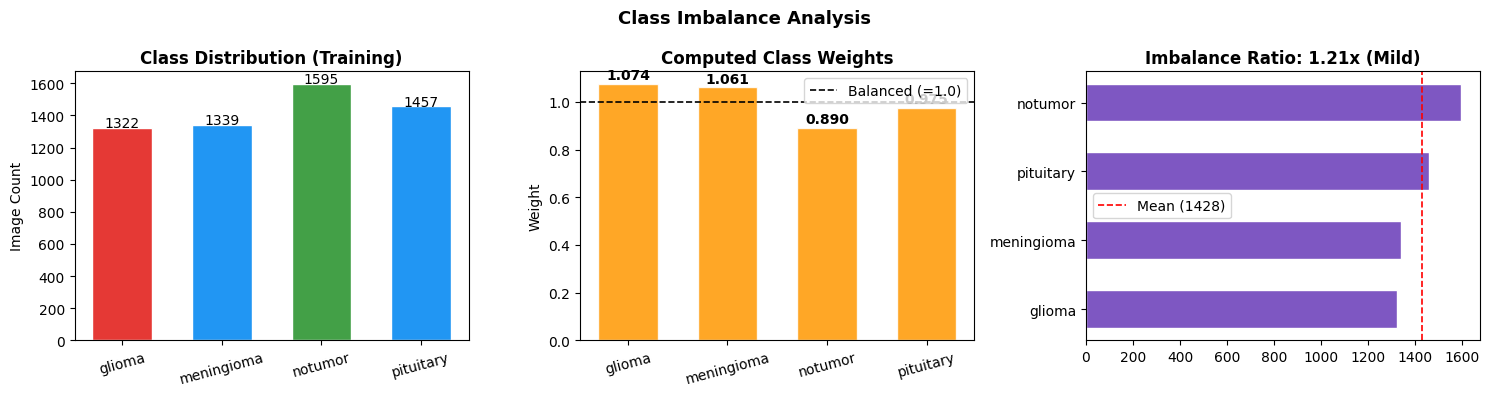


Class              Count        %     Weight  Interpretation
----------------------------------------------------------------------
glioma              1322    23.1%     1.0743  balanced
meningioma          1339    23.4%     1.0606  balanced
notumor             1595    27.9%     0.8904  down-weighted
pituitary           1457    25.5%     0.9747  balanced

Imbalance ratio: 1.21x


In [8]:
def compute_class_weights(labels):
    counts = Counter(labels.tolist())
    total  = sum(counts.values())
    w = np.array([1.0 / (counts.get(c, 1) / total) for c in range(num_classes)])
    w = w * len(w) / (w.sum() + 1e-12)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

def plot_class_distribution_and_weights(labels, class_names):
    counts     = Counter(labels.tolist())
    weights    = compute_class_weights(labels).cpu().numpy()
    count_vals = [counts[i] for i in range(len(class_names))]
    total      = sum(count_vals)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    colors = ["#E53935" if count_vals[i] == min(count_vals)
              else "#43A047" if count_vals[i] == max(count_vals)
              else "#2196F3" for i in range(len(class_names))]
    bars = axes[0].bar(class_names, count_vals, color=colors, edgecolor="white", width=0.6)
    axes[0].set_title("Class Distribution (Training)", fontweight="bold")
    axes[0].set_ylabel("Image Count")
    for bar, val in zip(bars, count_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(val), ha="center", fontsize=10)
    axes[0].tick_params(axis="x", rotation=15)

    w_colors = ["#E53935" if w > 1.2 else "#43A047" if w < 0.8 else "#FF9800"
                for w in weights]
    axes[1].bar(class_names, weights, color=w_colors, edgecolor="white", width=0.6, alpha=0.85)
    axes[1].axhline(y=1.0, color="black", linestyle="--", linewidth=1.2, label="Balanced (=1.0)")
    axes[1].set_title("Computed Class Weights", fontweight="bold")
    axes[1].set_ylabel("Weight"); axes[1].legend()
    for i, (name, w) in enumerate(zip(class_names, weights)):
        axes[1].text(i, w + 0.02, f"{w:.3f}", ha="center", fontsize=10, fontweight="bold")
    axes[1].tick_params(axis="x", rotation=15)

    imbalance_ratio = max(count_vals) / min(count_vals)
    sorted_idx = np.argsort(count_vals)
    axes[2].barh([class_names[i] for i in sorted_idx],
                  [count_vals[i] for i in sorted_idx],
                  color="#7E57C2", edgecolor="white", height=0.55)
    axes[2].axvline(x=total/len(count_vals), color="red", linestyle="--",
                    linewidth=1.2, label=f"Mean ({total//len(count_vals)})")
    severity = "Severe" if imbalance_ratio > 2 else "Moderate" if imbalance_ratio > 1.3 else "Mild"
    axes[2].set_title(f"Imbalance Ratio: {imbalance_ratio:.2f}x ({severity})", fontweight="bold")
    axes[2].legend()

    plt.suptitle("Class Imbalance Analysis", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    print("\n" + "="*70)
    print(f"{'Class':15s} {'Count':>8} {'%':>8} {'Weight':>10}  Interpretation")
    print("-"*70)
    for i, cls in enumerate(class_names):
        pct    = 100 * count_vals[i] / total
        interp = "UP-weighted" if weights[i] > 1.1 else "down-weighted" if weights[i] < 0.9 else "balanced"
        print(f"{cls:15s} {count_vals[i]:>8d} {pct:>7.1f}% {weights[i]:>10.4f}  {interp}")
    print(f"\nImbalance ratio: {imbalance_ratio:.2f}x")

plot_class_distribution_and_weights(train_labels, class_names)

## 9. Sample images

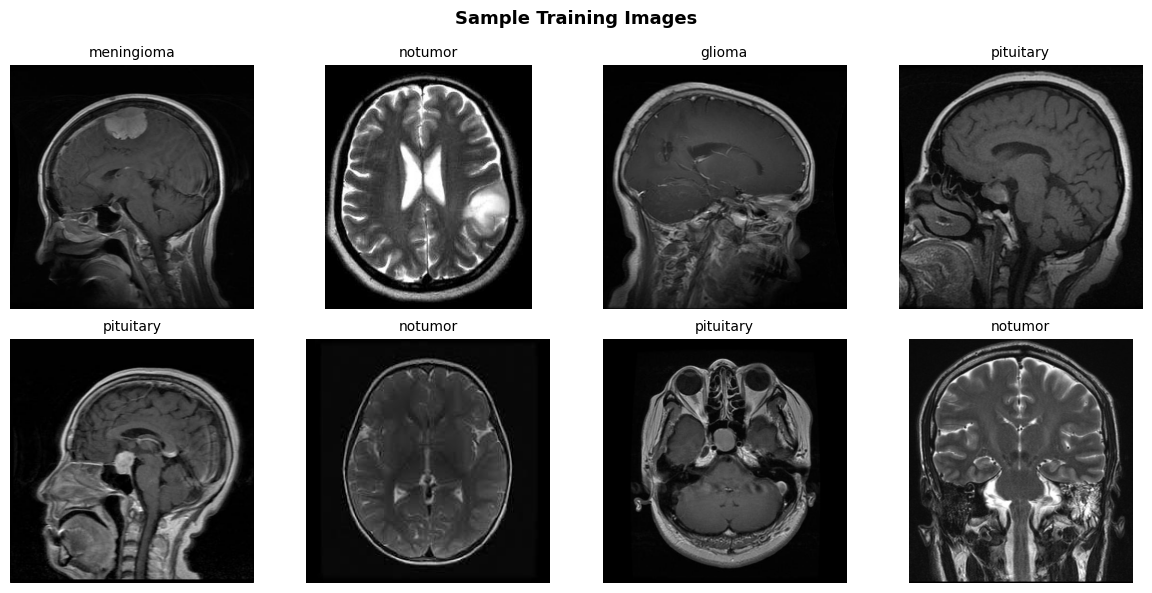

In [9]:
def show_samples(paths, labels, class_names, title=""):
    idxs = np.random.choice(len(paths), size=8, replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, idx in enumerate(idxs):
        axes.ravel()[i].imshow(Image.open(paths[idx]).convert("RGB"))
        axes.ravel()[i].set_title(class_names[labels[idx]], fontsize=10)
        axes.ravel()[i].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

show_samples(train_paths, train_labels, class_names, title="Sample Training Images")

## 10. EfficientNet-B3 model builder

In [10]:
def disable_inplace_activations(module):
    """Disable all inplace activation ops — required for Grad-CAM to work correctly.
    EfficientNet-B3 uses SiLU activations (not ReLU), so we check via hasattr.
    """
    for m in module.modules():
        if hasattr(m, 'inplace'):
            m.inplace = False

def build_efficientnet_b3(num_classes, fine_tune_blocks=3, dropout_rates=(0.5, 0.4)):
    """
    EfficientNet-B3 with ImageNet weights.

    Architecture overview:
      model.features[0]   : Stem Conv2dNormActivation
      model.features[1-7] : MBConv / FusedMBConv blocks (7 stages)
      model.features[8]   : Head Conv2dNormActivation  (1536 channels output)
      model.avgpool        : AdaptiveAvgPool2d
      model.classifier     : replaced with custom 2-layer head

    fine_tune_blocks : last N blocks of model.features to unfreeze
                       e.g. 3 → unfreeze features[6], features[7], features[8]
    """
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
    disable_inplace_activations(model)

    # Freeze all feature layers
    for p in model.features.parameters():
        p.requires_grad = False

    # Unfreeze last fine_tune_blocks blocks
    if fine_tune_blocks > 0:
        feature_blocks = list(model.features.children())   # 9 blocks: indices 0-8
        for block in feature_blocks[-fine_tune_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

    # Replace classifier with richer two-layer head (same structure as VGG16 version)
    in_features = model.classifier[1].in_features  # 1536 for EfficientNet-B3
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.SiLU(),
        nn.Dropout(dropout_rates[0]),
        nn.Linear(512, 256),
        nn.SiLU(),
        nn.Dropout(dropout_rates[1]),
        nn.Linear(256, num_classes),
    )
    return model.to(DEVICE)

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

_m = build_efficientnet_b3(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
_tot, _trn = count_params(_m)
print(f"EfficientNet-B3 Parameters:")
print(f"  Total     : {_tot:,}")
print(f"  Trainable : {_trn:,}  ({100*_trn/_tot:.1f}%)")
print(f"  Fine-tune : last {FINE_TUNE_AT} feature blocks (features[{9-FINE_TUNE_AT}] → features[8])")
del _m

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 120MB/s]


EfficientNet-B3 Parameters:
  Total     : 11,615,532
  Trainable : 9,425,378  (81.1%)
  Fine-tune : last 3 feature blocks (features[6] → features[8])


## 11. Best checkpoint tracker

In [11]:
class BestCheckpoint:
    """Single source of truth — tracks best epoch AND handles early stopping."""
    def __init__(self, patience=8, min_delta=1e-4):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best        = None
        self.counter     = 0
        self.should_stop = False

    def update(self, score, model, payload):
        if (self.best is None) or (score > self.best["score"] + self.min_delta):
            self.best = {
                "score":   score,
                "weights": {k: v.detach().cpu().clone()
                            for k, v in model.state_dict().items()},
                **payload,
            }
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def restore(self, model):
        if self.best is not None:
            model.load_state_dict(self.best["weights"])
        return model

print("✅ BestCheckpoint ready")

✅ BestCheckpoint ready


## 12. Metric utilities + Bootstrap CI

In [12]:
def softmax_np(logits):
    e = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def get_metrics(y_true, y_pred, probs=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    m = {
        "acc":   accuracy_score(y_true, y_pred),
        "prec":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "rec":   recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":    f1_score(y_true, y_pred, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "mcc":   matthews_corrcoef(y_true, y_pred),
    }
    if probs is not None:
        try:
            m["auc"] = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
        except Exception:
            m["auc"] = np.nan
    else:
        m["auc"] = np.nan
    return m

def get_clinical_metrics(y_true, y_pred):
    results = {}
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    for i, cls in enumerate(class_names):
        tp = int(np.sum((y_true == i) & (y_pred == i)))
        tn = int(np.sum((y_true != i) & (y_pred != i)))
        fp = int(np.sum((y_true != i) & (y_pred == i)))
        fn = int(np.sum((y_true == i) & (y_pred != i)))
        results[cls] = {
            "sensitivity": round(float(tp / (tp + fn + 1e-8)), 4),
            "specificity": round(float(tn / (tn + fp + 1e-8)), 4),
            "PPV":         round(float(tp / (tp + fp + 1e-8)), 4),
            "NPV":         round(float(tn / (tn + fn + 1e-8)), 4),
            "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        }
    return results

def bootstrap_ci(y_true, y_pred, probs=None, n=1000, seed=42):
    """Bootstrap 95% CI for all metrics."""
    rng = np.random.RandomState(seed)
    N   = len(y_true)
    cis = {"acc": [], "prec": [], "rec": [], "f1": [],
           "kappa": [], "mcc": [], "auc": []}

    for _ in range(n):
        idx = rng.choice(N, N, replace=True)
        yt  = np.asarray(y_true)[idx]
        yp  = np.asarray(y_pred)[idx]
        pp  = np.asarray(probs)[idx] if probs is not None else None
        if len(np.unique(yt)) < num_classes:
            continue
        m = get_metrics(yt, yp, pp)
        for k in cis:
            cis[k].append(m.get(k, np.nan))

    out = {}
    for k, vals in cis.items():
        arr = np.array(vals, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            out[k] = {"mean": np.nan, "lower": np.nan, "upper": np.nan}
        else:
            out[k] = {
                "mean":  float(np.mean(arr)),
                "lower": float(np.percentile(arr, 2.5)),
                "upper": float(np.percentile(arr, 97.5)),
            }
    return out

def normalize_cm_safe(cm):
    """Zero-safe row-wise normalization."""
    cm_sum = cm.sum(axis=1, keepdims=True)
    return np.divide(cm.astype(float), cm_sum,
                     out=np.zeros_like(cm, dtype=float),
                     where=cm_sum != 0)

print("✅ Metric utilities ready")

✅ Metric utilities ready


## 13. Plot utilities

In [13]:
def plot_history(history, fold):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train", color="#2196F3")
    axes[0].plot(history["val_loss"],   label="Val",   color="#FF5722")
    axes[0].set_title(f"{EXPERIMENT} Fold {fold} — Loss"); axes[0].legend()
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].plot(history["train_acc"], label="Train", color="#2196F3")
    axes[1].plot(history["val_acc"],   label="Val",   color="#FF5722")
    axes[1].set_title(f"{EXPERIMENT} Fold {fold} — Accuracy"); axes[1].legend()
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    plt.tight_layout(); plt.show()

def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = normalize_cm_safe(cm)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, data, fmt, t in zip(axes, [cm, cm_norm], ["d", ".2f"],
                                 [f"{title} (Raw)", f"{title} (Normalized)"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", ax=ax,
                    xticklabels=class_names, yticklabels=class_names)
        ax.set_title(t); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()

def plot_roc(y_true, probs, title_suffix=""):
    yb = label_binarize(y_true, classes=list(range(num_classes)))
    plt.figure(figsize=(7, 6))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(yb[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    fpr_m, tpr_m, _ = roc_curve(yb.ravel(), probs.ravel())
    plt.plot(fpr_m, tpr_m, "k--", label=f"micro (AUC={auc(fpr_m,tpr_m):.3f})")
    plt.plot([0,1],[0,1],"gray"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"ROC — {title_suffix}"); plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()

def plot_clinical_table(clinical_metrics, title="Clinical Metrics"):
    rows = []
    for cls, m in clinical_metrics.items():
        rows.append([cls, f"{m['sensitivity']:.4f}", f"{m['specificity']:.4f}",
                     f"{m['PPV']:.4f}", f"{m['NPV']:.4f}"])
    cols = ["Class", "Sensitivity", "Specificity", "PPV", "NPV"]
    fig, ax = plt.subplots(figsize=(10, 2 + len(rows)*0.5))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=cols, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.8)
    for j in range(len(cols)):
        tbl[(0, j)].set_facecolor("#2196F3")
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(rows)+1):
        for j in range(len(cols)):
            tbl[(i, j)].set_facecolor("#f0f4ff" if i%2==0 else "white")
    plt.title(title, fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout(); plt.show()

def plot_roc_per_class(y_true, probs, title_suffix="", save_dir=None):
    """Per-class ROC curves as individual subplot grid — publication-ready."""
    yb = label_binarize(y_true, classes=list(range(num_classes)))
    cols = min(num_classes, 4)
    rows = (num_classes + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes_flat = axes.ravel() if hasattr(axes, "ravel") else [axes]

    aucs = []
    for i, (cls, ax) in enumerate(zip(class_names, axes_flat)):
        fpr, tpr, _ = roc_curve(yb[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color="#1565C0", lw=2, label=f"AUC = {roc_auc:.3f}")
        ax.fill_between(fpr, tpr, alpha=0.08, color="#1565C0")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
        ax.set_xlabel("False Positive Rate", fontsize=9)
        ax.set_ylabel("True Positive Rate", fontsize=9)
        ax.set_title(f"Class: {cls}", fontsize=10, fontweight="bold")
        ax.legend(loc="lower right", fontsize=9)
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[num_classes:]:
        ax.axis("off")

    macro_auc = float(roc_auc_score(yb, probs, multi_class="ovr", average="macro"))
    plt.suptitle(
        f"Per-Class ROC Curves — {title_suffix}\nMacro AUC = {macro_auc:.4f}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, f"roc_per_class_{title_suffix.replace(' ', '_')}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  ROC figure saved → {path}")
    plt.show()
    return aucs

print("✅ Plot utilities ready")

✅ Plot utilities ready


## 14. Training function (one fold)

In [14]:
def train_one_fold(train_loader, val_loader, model, criterion, optimizer, fold_no):
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": [],
               "train_f1_ema": [], "val_f1": []}
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=LR_FACTOR,
        patience=LR_PATIENCE, min_lr=LR_MIN)
    scaler  = GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))
    tracker = BestCheckpoint(patience=PATIENCE)
    train_f1_ema = None

    fold_start = time.time()

    for epoch in range(EPOCHS):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        tr_preds, tr_labels = [], []

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            if USE_AMP and DEVICE.type == "cuda":
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, lbls)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                out  = model(imgs)
                loss = criterion(out, lbls)
                loss.backward()
                optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == lbls).sum().item()
            total    += imgs.size(0)
            tr_preds.extend(out.argmax(1).cpu().numpy())
            tr_labels.extend(lbls.cpu().numpy())

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        val_preds, val_lbls_all, val_logits = [], [], []

        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, lbls)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == lbls).sum().item()
                v_total   += imgs.size(0)
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_lbls_all.extend(lbls.cpu().numpy())
                val_logits.append(out.cpu().numpy())

        train_loss = run_loss / max(total, 1)
        train_acc  = correct  / max(total, 1)
        val_loss   = v_loss   / max(v_total, 1)
        val_acc    = v_correct / max(v_total, 1)

        probs_np = softmax_np(np.concatenate(val_logits))
        val_m    = get_metrics(val_lbls_all, val_preds, probs_np)
        tr_f1    = f1_score(tr_labels, tr_preds, average="macro", zero_division=0)

        train_f1_ema = tr_f1 if train_f1_ema is None else (
            0.3 * tr_f1 + 0.7 * train_f1_ema  # EMA smoothing (alpha=0.3)
            )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1_ema"].append(train_f1_ema)
        history["val_f1"].append(val_m["f1"])

        print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
              f"Train L/A: {train_loss:.4f}/{train_acc:.4f} | "
              f"Val L/A: {val_loss:.4f}/{val_acc:.4f} | "
              f"ValF1: {val_m['f1']:.4f} | ValAUC: {val_m['auc']:.4f}")

        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_m[BEST_METRIC])
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr != old_lr:
            print(f"  [LR] {old_lr:.2e} → {new_lr:.2e}")

        payload = {
            "epoch":        epoch + 1,
            "y_true":       np.array(val_lbls_all),
            "y_pred":       np.array(val_preds),
            "probs":        probs_np,
            "train_acc":    train_acc,
            "train_f1_ema": train_f1_ema,
            "val_acc":      val_acc,
            "val_f1":       val_m["f1"],
            "val_loss":     val_loss,
        }
        if tracker.update(val_m[BEST_METRIC], model, payload):
            print(f"  [EarlyStopping] Best {BEST_METRIC.upper()}: "
                  f"{tracker.best['score']:.4f} @ epoch {tracker.best['epoch']}")
            break

    fold_time = time.time() - fold_start
    print(f"  Training time: {fold_time/60:.1f} min")
    tracker.restore(model)
    return history, tracker.best, model, fold_time

print("✅ Training function ready")

✅ Training function ready


## 15. Run 5-Fold Cross Validation

⏱️ **This takes ~2-3 hours on GPU**


========================= Fold 1/5 =========================
Epoch   1/50 | Train L/A: 0.6440/0.7965 | Val L/A: 34.3756/0.9143 | ValF1: 0.9108 | ValAUC: 0.9825
Epoch   2/50 | Train L/A: 0.2245/0.9232 | Val L/A: 52.4938/0.9554 | ValF1: 0.9534 | ValAUC: 0.9898
Epoch   3/50 | Train L/A: 0.1412/0.9532 | Val L/A: 73.3706/0.9720 | ValF1: 0.9711 | ValAUC: 0.9912
Epoch   4/50 | Train L/A: 0.1027/0.9667 | Val L/A: 111.8229/0.9729 | ValF1: 0.9721 | ValAUC: 0.9913
Epoch   5/50 | Train L/A: 0.0811/0.9746 | Val L/A: 85.0635/0.9781 | ValF1: 0.9776 | ValAUC: 0.9906
Epoch   6/50 | Train L/A: 0.0670/0.9775 | Val L/A: 262.1414/0.9738 | ValF1: 0.9734 | ValAUC: 0.9856
Epoch   7/50 | Train L/A: 0.0654/0.9772 | Val L/A: 272.6499/0.9773 | ValF1: 0.9767 | ValAUC: 0.9903
Epoch   8/50 | Train L/A: 0.0490/0.9821 | Val L/A: 32.5868/0.9720 | ValF1: 0.9710 | ValAUC: 0.9908
Epoch   9/50 | Train L/A: 0.0510/0.9849 | Val L/A: 378.0805/0.9834 | ValF1: 0.9832 | ValAUC: 0.9921
Epoch  10/50 | Train L/A: 0.0316/0.9908 | V

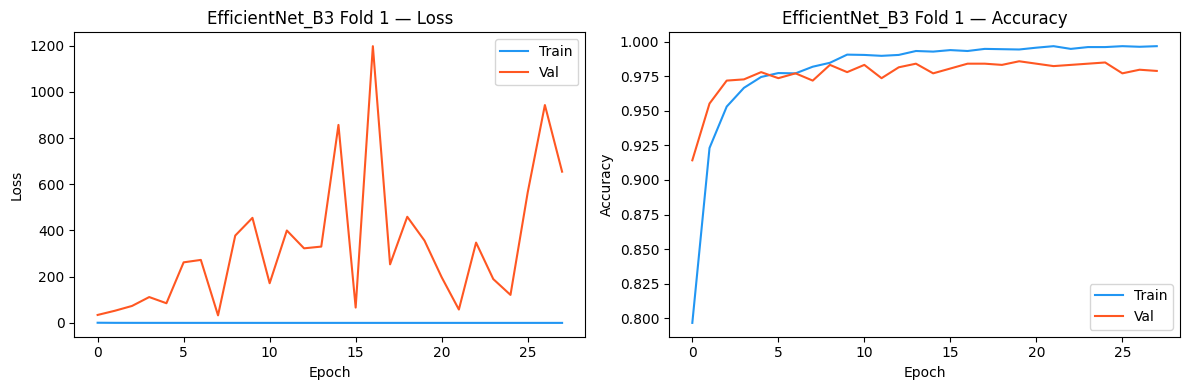


Classification Report — Fold 1:
              precision    recall  f1-score   support

      glioma     0.9740    0.9887    0.9813       265
  meningioma     0.9813    0.9776    0.9794       268
     notumor     0.9905    0.9781    0.9842       319
   pituitary     0.9966    1.0000    0.9983       291

    accuracy                         0.9860      1143
   macro avg     0.9856    0.9861    0.9858      1143
weighted avg     0.9860    0.9860    0.9860      1143

Fold 1: Acc=0.9860 | F1=0.9858 | AUC=0.9926 | Kappa=0.9813 | MCC=0.9813


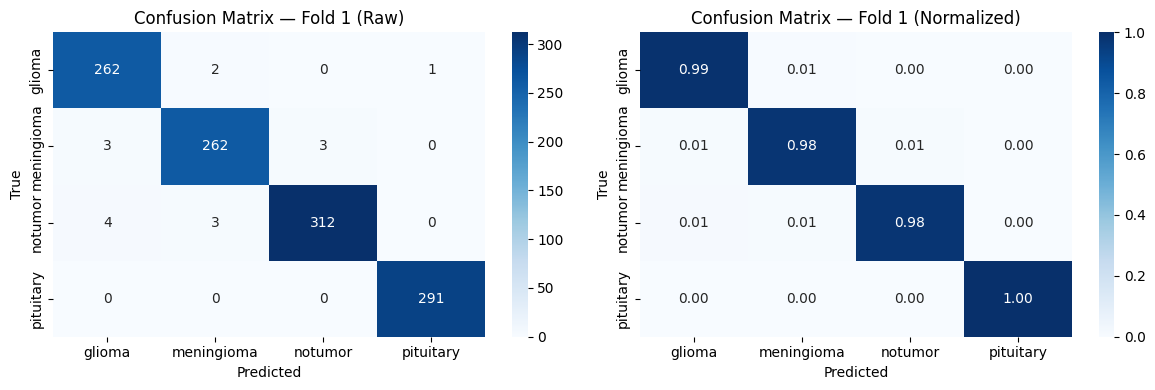

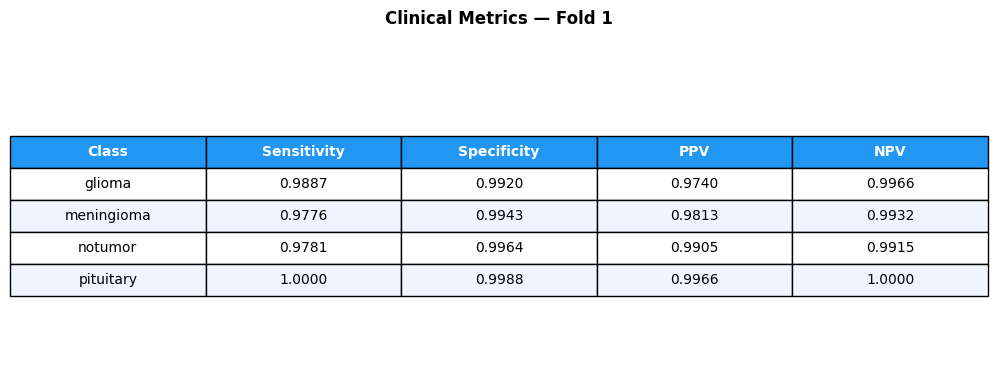

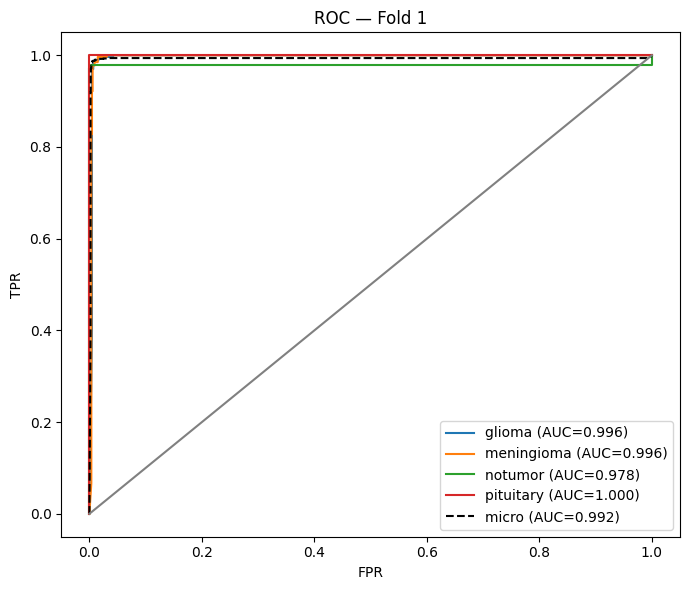

  Checkpoint → checkpoints_EfficientNet_B3_Dataset1/EfficientNet_B3_fold1.pt
  New best fold! F1 = 0.9858

========================= Fold 2/5 =========================
Epoch   1/50 | Train L/A: 0.6418/0.7937 | Val L/A: 89.8810/0.9090 | ValF1: 0.9052 | ValAUC: 0.9807
Epoch   2/50 | Train L/A: 0.2199/0.9247 | Val L/A: 19.1988/0.9554 | ValF1: 0.9540 | ValAUC: 0.9874
Epoch   3/50 | Train L/A: 0.1441/0.9490 | Val L/A: 309.6759/0.9615 | ValF1: 0.9601 | ValAUC: 0.9917
Epoch   4/50 | Train L/A: 0.0996/0.9648 | Val L/A: 477.2991/0.9703 | ValF1: 0.9692 | ValAUC: 0.9933
Epoch   5/50 | Train L/A: 0.0864/0.9711 | Val L/A: 265.9652/0.9720 | ValF1: 0.9710 | ValAUC: 0.9938
Epoch   6/50 | Train L/A: 0.0650/0.9779 | Val L/A: 298.4194/0.9764 | ValF1: 0.9759 | ValAUC: 0.9895
Epoch   7/50 | Train L/A: 0.0696/0.9768 | Val L/A: 1150.0649/0.9606 | ValF1: 0.9600 | ValAUC: 0.9823
Epoch   8/50 | Train L/A: 0.0506/0.9827 | Val L/A: 305.0003/0.9738 | ValF1: 0.9731 | ValAUC: 0.9888
Epoch   9/50 | Train L/A: 0.0388/

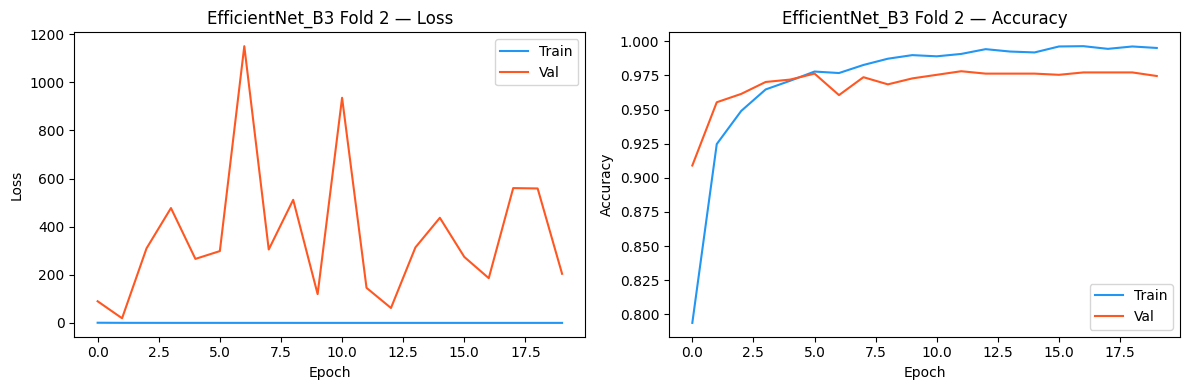


Classification Report — Fold 2:
              precision    recall  f1-score   support

      glioma     0.9846    0.9623    0.9733       265
  meningioma     0.9489    0.9738    0.9612       267
     notumor     1.0000    0.9812    0.9905       319
   pituitary     0.9764    0.9932    0.9847       292

    accuracy                         0.9781      1143
   macro avg     0.9775    0.9776    0.9774      1143
weighted avg     0.9785    0.9781    0.9782      1143

Fold 2: Acc=0.9781 | F1=0.9774 | AUC=0.9941 | Kappa=0.9708 | MCC=0.9709


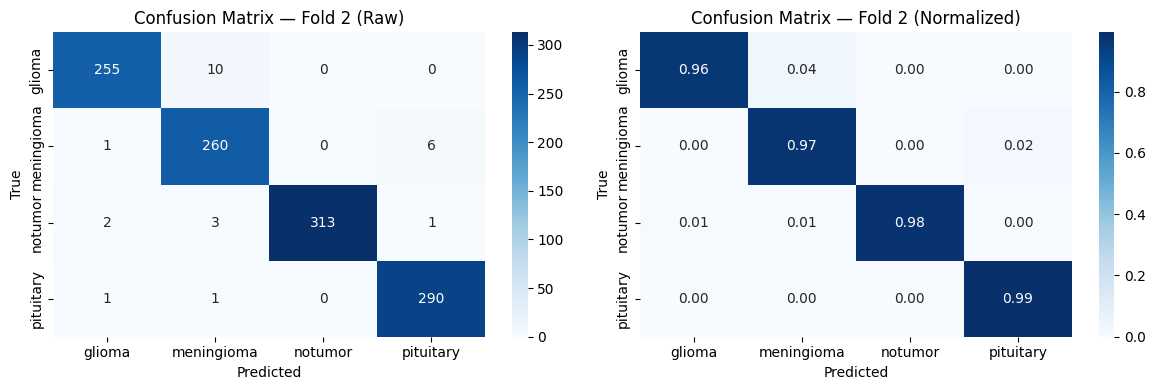

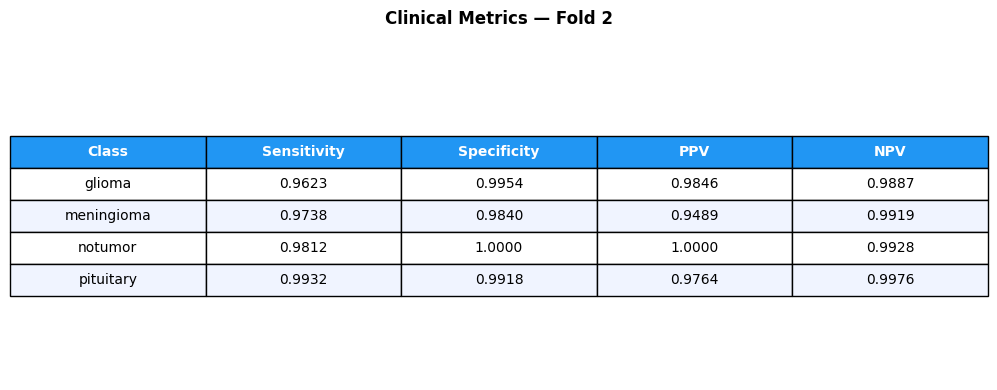

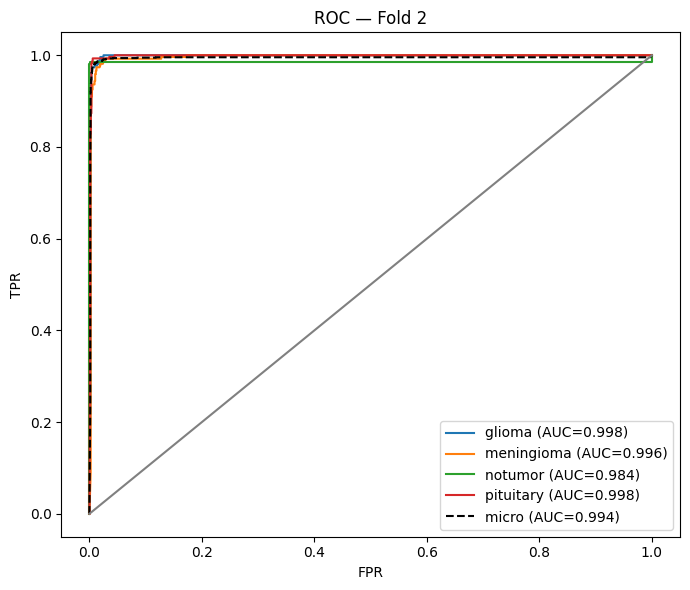

  Checkpoint → checkpoints_EfficientNet_B3_Dataset1/EfficientNet_B3_fold2.pt

========================= Fold 3/5 =========================
Epoch   1/50 | Train L/A: 0.6339/0.8037 | Val L/A: 74.5024/0.9186 | ValF1: 0.9160 | ValAUC: 0.9734
Epoch   2/50 | Train L/A: 0.2204/0.9245 | Val L/A: 219.5852/0.9510 | ValF1: 0.9500 | ValAUC: 0.9866
Epoch   3/50 | Train L/A: 0.1429/0.9516 | Val L/A: 136.2213/0.9510 | ValF1: 0.9493 | ValAUC: 0.9862
Epoch   4/50 | Train L/A: 0.1122/0.9643 | Val L/A: 365.7447/0.9685 | ValF1: 0.9682 | ValAUC: 0.9895
Epoch   5/50 | Train L/A: 0.0777/0.9735 | Val L/A: 514.9271/0.9685 | ValF1: 0.9678 | ValAUC: 0.9885
Epoch   6/50 | Train L/A: 0.0666/0.9770 | Val L/A: 663.6151/0.9676 | ValF1: 0.9670 | ValAUC: 0.9854
Epoch   7/50 | Train L/A: 0.0653/0.9807 | Val L/A: 1610.4531/0.9729 | ValF1: 0.9728 | ValAUC: 0.9837
Epoch   8/50 | Train L/A: 0.0461/0.9840 | Val L/A: 600.5219/0.9790 | ValF1: 0.9785 | ValAUC: 0.9889
Epoch   9/50 | Train L/A: 0.0463/0.9829 | Val L/A: 1682.6949/

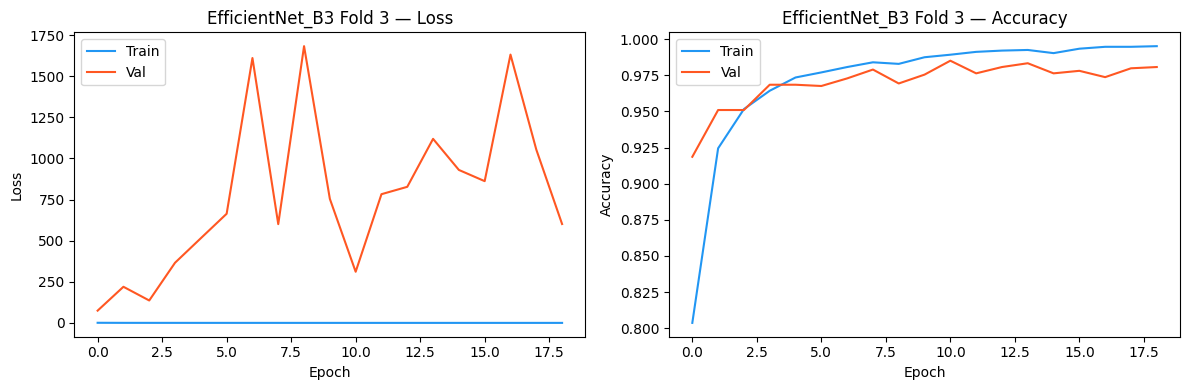


Classification Report — Fold 3:
              precision    recall  f1-score   support

      glioma     0.9741    0.9962    0.9850       264
  meningioma     0.9704    0.9776    0.9740       268
     notumor     0.9936    0.9781    0.9858       319
   pituitary     1.0000    0.9897    0.9948       292

    accuracy                         0.9851      1143
   macro avg     0.9845    0.9854    0.9849      1143
weighted avg     0.9853    0.9851    0.9852      1143

Fold 3: Acc=0.9851 | F1=0.9849 | AUC=0.9922 | Kappa=0.9801 | MCC=0.9802


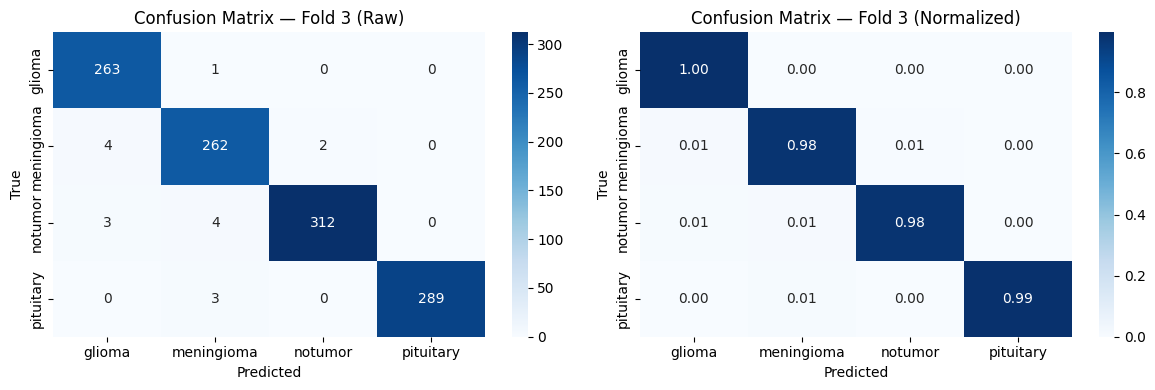

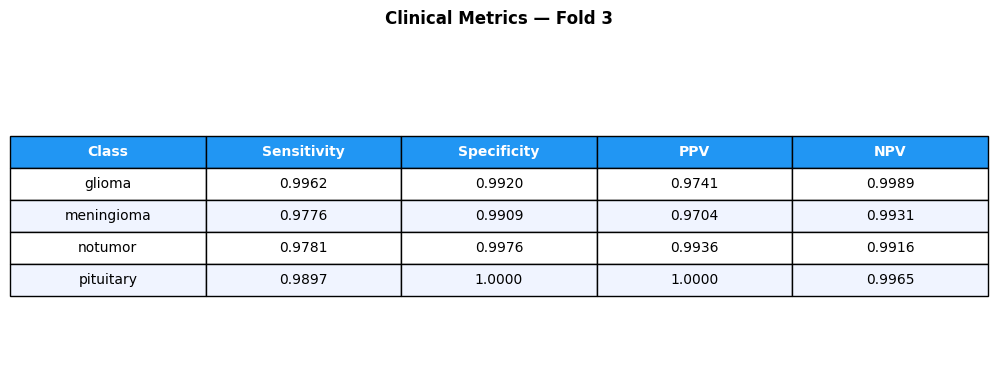

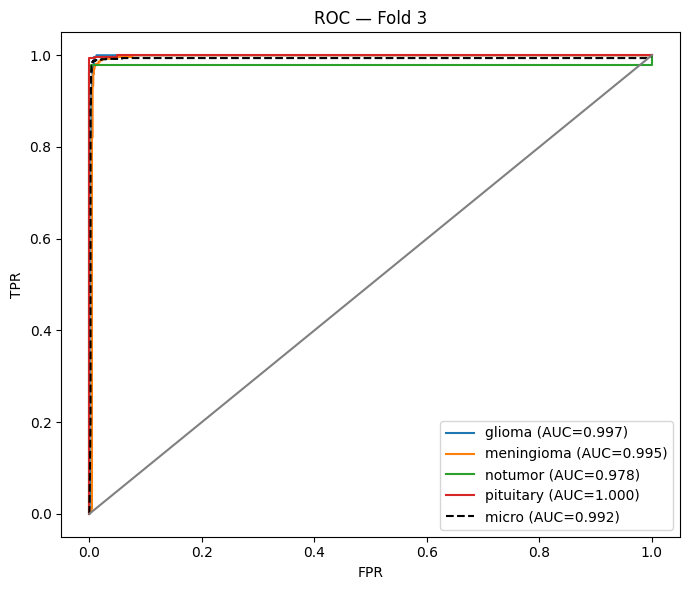

  Checkpoint → checkpoints_EfficientNet_B3_Dataset1/EfficientNet_B3_fold3.pt

========================= Fold 4/5 =========================
Epoch   1/50 | Train L/A: 0.6495/0.7825 | Val L/A: 10.6244/0.9186 | ValF1: 0.9142 | ValAUC: 0.9845
Epoch   2/50 | Train L/A: 0.2210/0.9274 | Val L/A: 41.2258/0.9448 | ValF1: 0.9434 | ValAUC: 0.9900
Epoch   3/50 | Train L/A: 0.1444/0.9477 | Val L/A: 14.4320/0.9694 | ValF1: 0.9686 | ValAUC: 0.9935
Epoch   4/50 | Train L/A: 0.1229/0.9597 | Val L/A: 37.3771/0.9746 | ValF1: 0.9742 | ValAUC: 0.9949
Epoch   5/50 | Train L/A: 0.0938/0.9696 | Val L/A: 53.3712/0.9729 | ValF1: 0.9726 | ValAUC: 0.9936
Epoch   6/50 | Train L/A: 0.0740/0.9748 | Val L/A: 99.1501/0.9711 | ValF1: 0.9704 | ValAUC: 0.9929
Epoch   7/50 | Train L/A: 0.0595/0.9821 | Val L/A: 28.4606/0.9807 | ValF1: 0.9806 | ValAUC: 0.9952
Epoch   8/50 | Train L/A: 0.0508/0.9829 | Val L/A: 183.9775/0.9807 | ValF1: 0.9805 | ValAUC: 0.9933
Epoch   9/50 | Train L/A: 0.0419/0.9867 | Val L/A: 27.2529/0.9755 | 

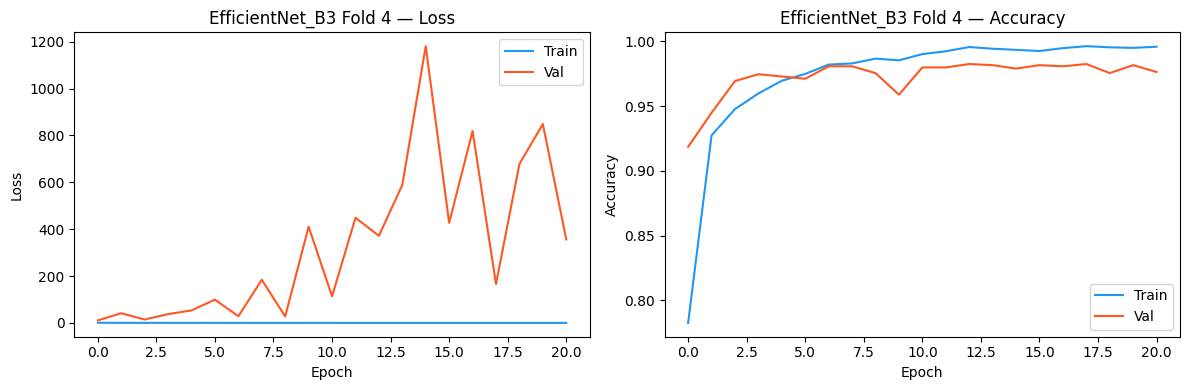


Classification Report — Fold 4:
              precision    recall  f1-score   support

      glioma     0.9701    0.9848    0.9774       264
  meningioma     0.9706    0.9851    0.9778       268
     notumor     0.9968    0.9749    0.9857       319
   pituitary     0.9897    0.9863    0.9880       291

    accuracy                         0.9825      1142
   macro avg     0.9818    0.9828    0.9822      1142
weighted avg     0.9827    0.9825    0.9825      1142

Fold 4: Acc=0.9825 | F1=0.9822 | AUC=0.9946 | Kappa=0.9766 | MCC=0.9767


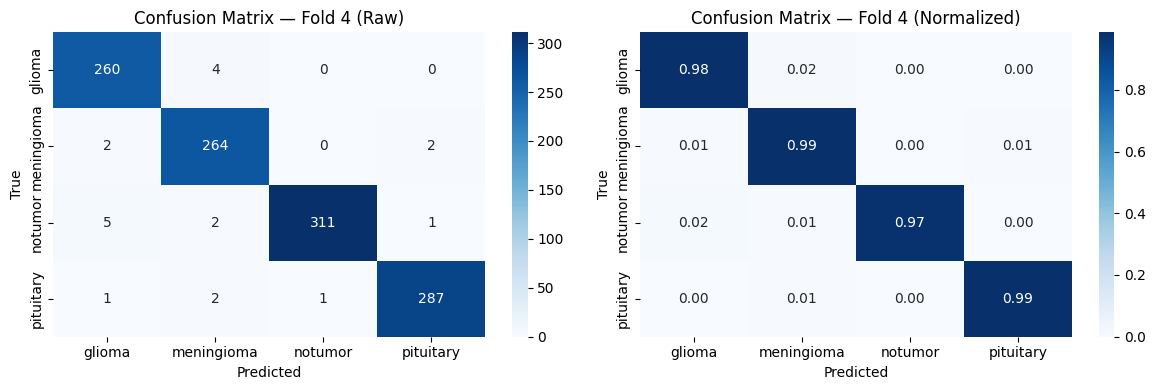

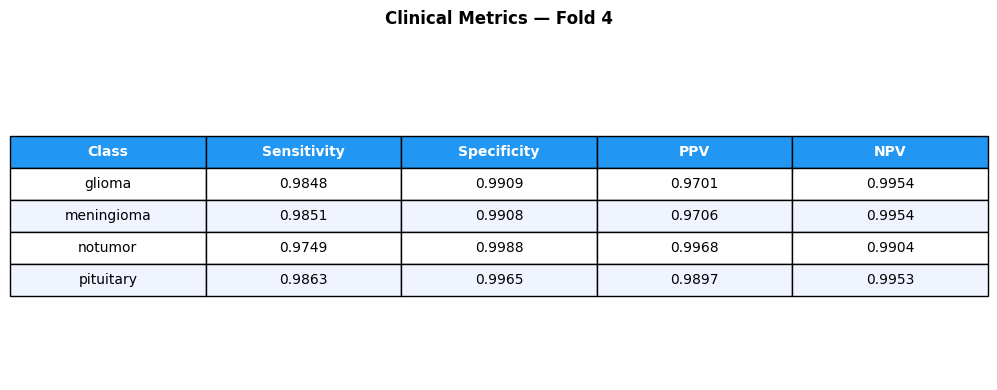

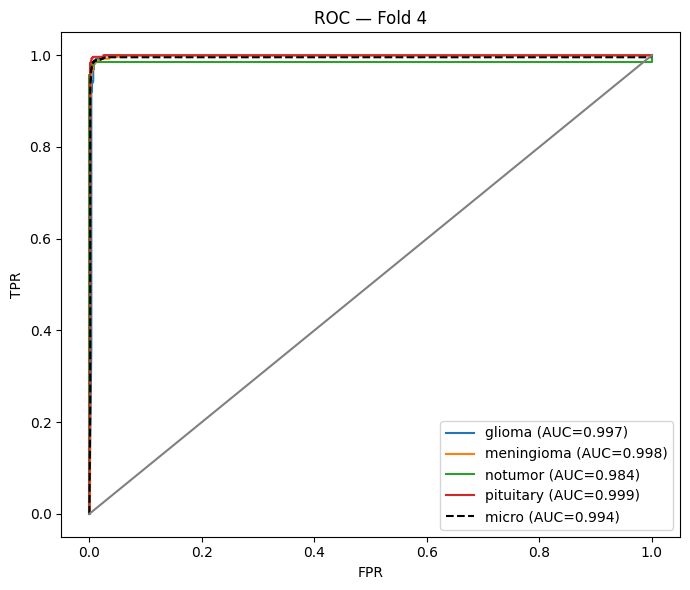

  Checkpoint → checkpoints_EfficientNet_B3_Dataset1/EfficientNet_B3_fold4.pt

========================= Fold 5/5 =========================
Epoch   1/50 | Train L/A: 0.6578/0.7779 | Val L/A: 25.2410/0.8897 | ValF1: 0.8780 | ValAUC: 0.9811
Epoch   2/50 | Train L/A: 0.2235/0.9254 | Val L/A: 89.6995/0.9440 | ValF1: 0.9415 | ValAUC: 0.9866
Epoch   3/50 | Train L/A: 0.1483/0.9492 | Val L/A: 75.5185/0.9650 | ValF1: 0.9640 | ValAUC: 0.9886
Epoch   4/50 | Train L/A: 0.1006/0.9646 | Val L/A: 2265.5157/0.9694 | ValF1: 0.9690 | ValAUC: 0.9876
Epoch   5/50 | Train L/A: 0.0811/0.9727 | Val L/A: 673.3061/0.9658 | ValF1: 0.9656 | ValAUC: 0.9844
Epoch   6/50 | Train L/A: 0.0675/0.9783 | Val L/A: 334.9057/0.9615 | ValF1: 0.9607 | ValAUC: 0.9889
Epoch   7/50 | Train L/A: 0.0574/0.9797 | Val L/A: 562.1767/0.9772 | ValF1: 0.9772 | ValAUC: 0.9905
Epoch   8/50 | Train L/A: 0.0483/0.9836 | Val L/A: 1289.6325/0.9764 | ValF1: 0.9762 | ValAUC: 0.9895
Epoch   9/50 | Train L/A: 0.0418/0.9842 | Val L/A: 833.5912/0.

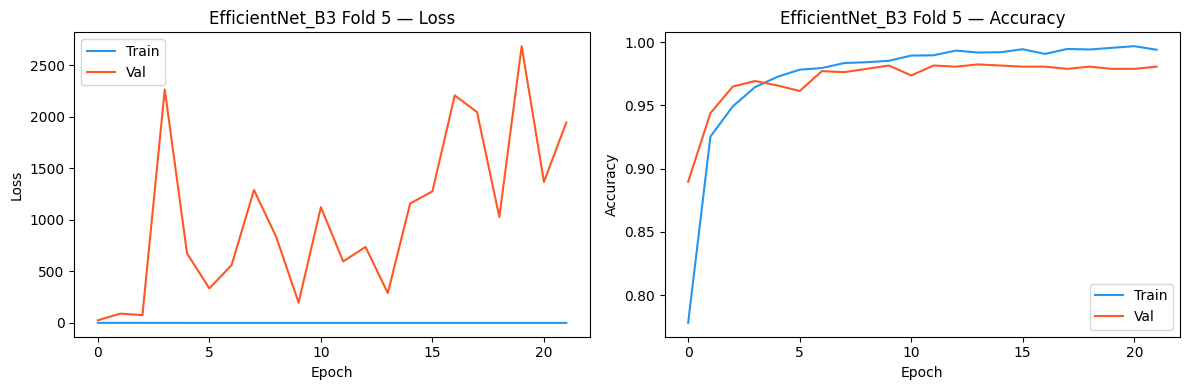


Classification Report — Fold 5:
              precision    recall  f1-score   support

      glioma     0.9887    0.9924    0.9905       264
  meningioma     0.9599    0.9813    0.9705       268
     notumor     0.9904    0.9655    0.9778       319
   pituitary     0.9897    0.9931    0.9914       291

    accuracy                         0.9825      1142
   macro avg     0.9822    0.9831    0.9826      1142
weighted avg     0.9826    0.9825    0.9825      1142

Fold 5: Acc=0.9825 | F1=0.9826 | AUC=0.9904 | Kappa=0.9766 | MCC=0.9767


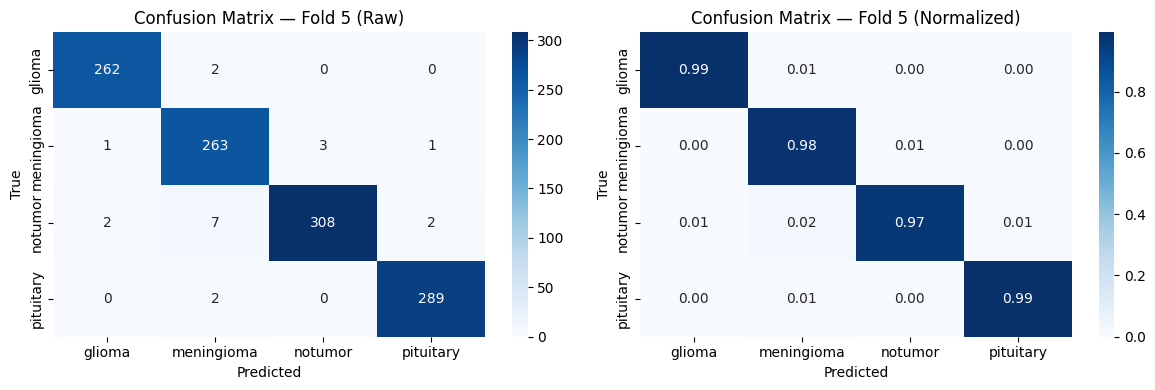

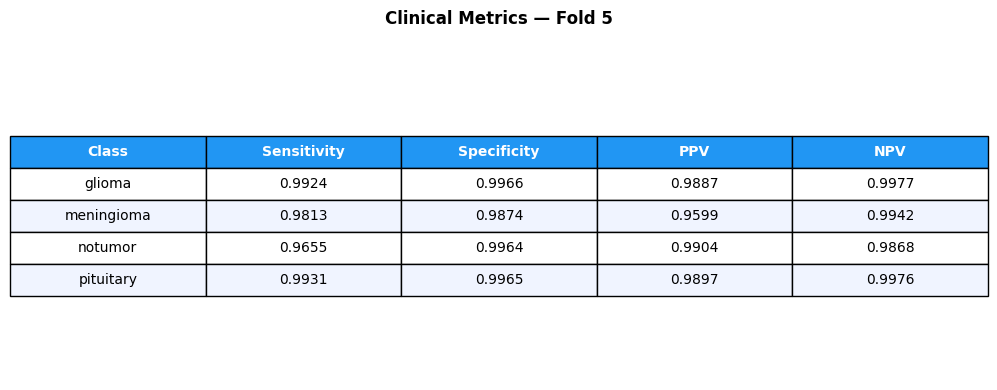

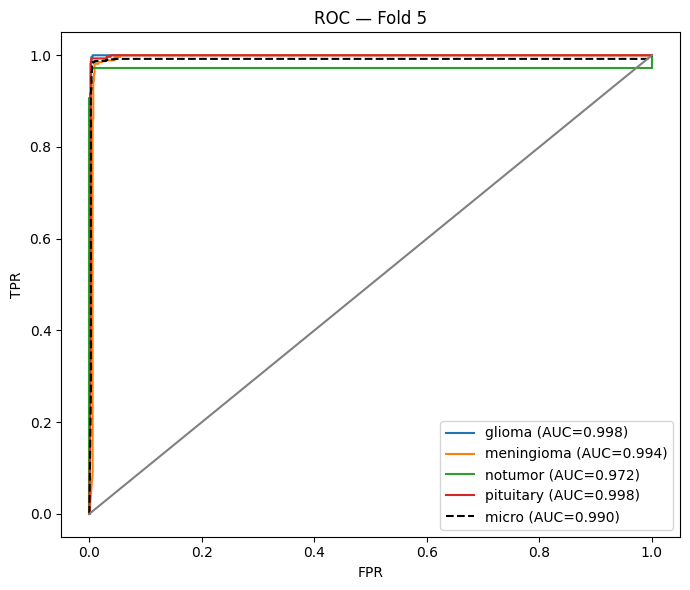

  Checkpoint → checkpoints_EfficientNet_B3_Dataset1/EfficientNet_B3_fold5.pt

✅ Cross-validation complete


In [15]:
_m_tmp = build_efficientnet_b3(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
_tot, _trn = count_params(_m_tmp)
del _m_tmp

MODEL_INFO = {
    "architecture":      "EfficientNet-B3",
    "pretrained":        "ImageNet",
    "fine_tune_blocks":  FINE_TUNE_AT,
    "total_params":      int(_tot),
    "trainable_params":  int(_trn),
    "trainable_pct":     round(100 * _trn / _tot, 2),
    "img_size":          IMG_SIZE,
    "batch_size":        BATCH_SIZE,
    "epochs_max":        EPOCHS,
    "patience":          PATIENCE,
    "optimizer":         "AdamW",
    "learning_rate":     LEARNING_RATE,
    "weight_decay":      WEIGHT_DECAY,
    "loss_function":     "CrossEntropyLoss (per-fold class weights)",
    "scheduler":         f"ReduceLROnPlateau(factor={LR_FACTOR}, patience={LR_PATIENCE})",
    "dropout_rates":     DROPOUT_RATES,
    "selection_metric":  BEST_METRIC,
    "augmentations":     AUG_LIST,
    "seed":              SEED,
    "amp":               USE_AMP,
    "device":            str(DEVICE),
    "pytorch":           torch.__version__,
    "platform":          platform.platform(),
    "bootstrap_n":       BOOTSTRAP_N,
}

kf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
all_fold_metrics = []
best_global_score = -1
best_fold_path    = None
best_fold_no      = None

for fold_no, (tr_idx, val_idx) in enumerate(
        kf.split(train_paths, train_labels), start=1):
    print(f"\n{'='*25} Fold {fold_no}/{KFOLDS} {'='*25}")

    tr_p, val_p = train_paths[tr_idx], train_paths[val_idx]
    tr_l, val_l = train_labels[tr_idx], train_labels[val_idx]

    train_loader = DataLoader(
        BrainTumorDataset(tr_p, tr_l, train_transform),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(
        BrainTumorDataset(val_p, val_l, test_transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    set_seed(SEED)  # Reset seed each fold for reproducibility
    model     = build_efficientnet_b3(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
    cw        = compute_class_weights(tr_l)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    history, best, model, fold_time = train_one_fold(
        train_loader, val_loader, model, criterion, optimizer, fold_no)

    plot_history(history, fold_no)

    y_true, y_pred, probs = best["y_true"], best["y_pred"], best["probs"]
    metrics = get_metrics(y_true, y_pred, probs)
    metrics.update({
        "best_epoch":     best["epoch"],
        "fold":           fold_no,
        "train_time_sec": fold_time,
        "train_acc":      best["train_acc"],
        "train_f1_ema":   best["train_f1_ema"],
        "val_acc":        best["val_acc"],
        "val_f1":         best["val_f1"],
        "clinical":       get_clinical_metrics(y_true, y_pred),
    })

    print(f"\nClassification Report — Fold {fold_no}:")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                 digits=4, zero_division=0))
    print(f"Fold {fold_no}: Acc={metrics['acc']:.4f} | F1={metrics['f1']:.4f} | "
          f"AUC={metrics['auc']:.4f} | Kappa={metrics['kappa']:.4f} | "
          f"MCC={metrics['mcc']:.4f}")

    plot_cm(y_true, y_pred, title=f"Confusion Matrix — Fold {fold_no}")
    plot_clinical_table(metrics["clinical"], title=f"Clinical Metrics — Fold {fold_no}")
    try:
        plot_roc(y_true, probs, title_suffix=f"Fold {fold_no}")
    except Exception as e:
        print(f"[WARN] ROC plot skipped: {e}")

    ckpt_path = os.path.join(CKPT_DIR, f"{EXPERIMENT}_fold{fold_no}.pt")
    torch.save({
        "state_dict":  model.state_dict(),
        "classes":     class_names,
        "fold":        fold_no,
        "metrics":     metrics,
        "model_info":  MODEL_INFO,
        "run_id":      RUN_ID,
    }, ckpt_path)

    np.save(os.path.join(ARTIFACTS_DIR, f"val_true_fold{fold_no}.npy"),  y_true)
    np.save(os.path.join(ARTIFACTS_DIR, f"val_pred_fold{fold_no}.npy"),  y_pred)
    np.save(os.path.join(ARTIFACTS_DIR, f"val_probs_fold{fold_no}.npy"), probs)

    print(f"  Checkpoint → {ckpt_path}")

    if metrics[BEST_METRIC] > best_global_score:
        best_global_score = metrics[BEST_METRIC]
        best_fold_path    = ckpt_path
        best_fold_no      = fold_no
        print(f"  New best fold! {BEST_METRIC.upper()} = {best_global_score:.4f}")

    all_fold_metrics.append(metrics)

print("\n✅ Cross-validation complete")

## 16. CV Summary

In [16]:
print(f"\n{'='*60}")
print(f"{EXPERIMENT} — 5-Fold CV Summary (Best by: {BEST_METRIC.upper()})")
print(f"{'='*60}")
for key in ["acc", "prec", "rec", "f1", "auc", "kappa", "mcc"]:
    vals = np.array([m[key] for m in all_fold_metrics], dtype=float)
    marker = " ← selection metric" if key == BEST_METRIC else ""
    print(f"  {key:6s}: {np.nanmean(vals):.4f} ± {np.nanstd(vals):.4f}{marker}")

times = [m["train_time_sec"] for m in all_fold_metrics]
print(f"\n  Avg fold time : {np.mean(times)/60:.1f} min")
print(f"  Total time    : {sum(times)/60:.1f} min")
print(f"  Best fold     : Fold {best_fold_no} | {BEST_METRIC.upper()}={best_global_score:.4f}")

print(f"\n{'='*60}")
print("Aggregated Clinical Metrics (Mean ± Std across folds)")
print(f"{'='*60}")
print(f"{'Class':15s} {'Sensitivity':>14} {'Specificity':>14} {'PPV':>10} {'NPV':>10}")
print("-" * 65)
for cls in class_names:
    row = f"{cls:15s}"
    for k in ["sensitivity", "specificity", "PPV", "NPV"]:
        vals = [m["clinical"][cls][k] for m in all_fold_metrics]
        row += f" {np.mean(vals):>7.4f}±{np.std(vals):.4f}"
    print(row)


EfficientNet_B3 — 5-Fold CV Summary (Best by: F1)
  acc   : 0.9828 ± 0.0027
  prec  : 0.9823 ± 0.0028
  rec   : 0.9830 ± 0.0030
  f1    : 0.9826 ± 0.0029 ← selection metric
  auc   : 0.9928 ± 0.0015
  kappa : 0.9771 ± 0.0037
  mcc   : 0.9771 ± 0.0037

  Avg fold time : 31.4 min
  Total time    : 156.9 min
  Best fold     : Fold 1 | F1=0.9858

Aggregated Clinical Metrics (Mean ± Std across folds)
Class              Sensitivity    Specificity        PPV        NPV
-----------------------------------------------------------------
glioma           0.9849±0.0119  0.9934±0.0022  0.9783±0.0071  0.9955±0.0036
meningioma       0.9791±0.0038  0.9895±0.0035  0.9662±0.0110  0.9936±0.0012
notumor          0.9756±0.0054  0.9978±0.0014  0.9943±0.0037  0.9906±0.0021
pituitary        0.9925±0.0045  0.9967±0.0028  0.9905±0.0081  0.9974±0.0016


## 17. Overfitting analysis

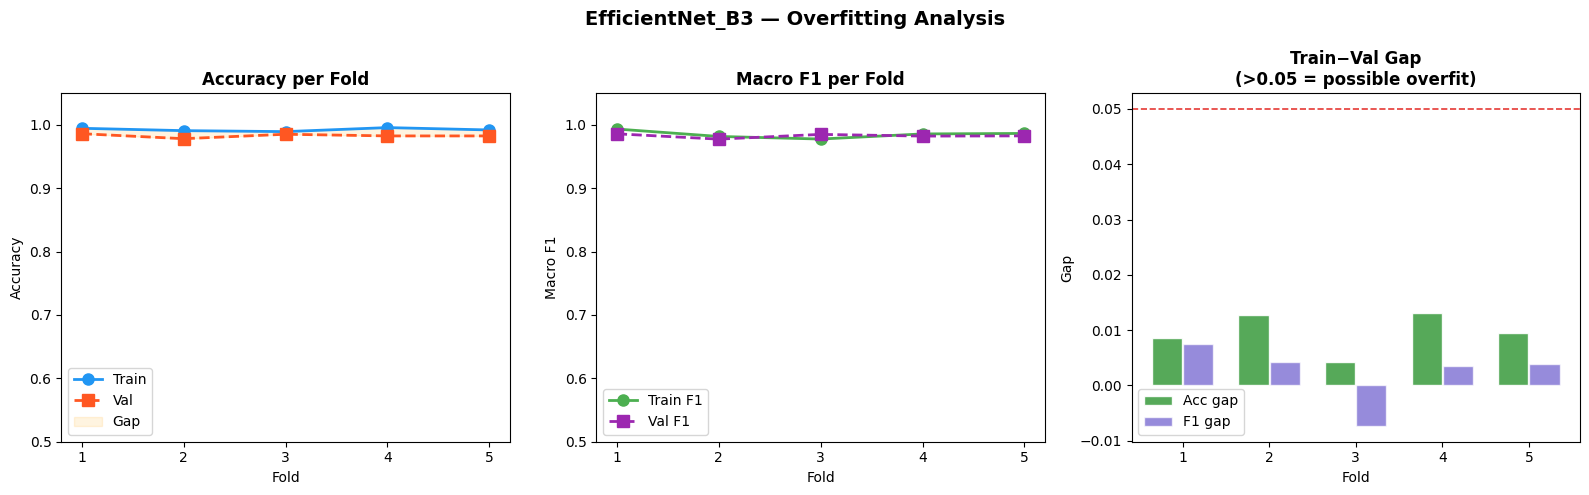


Fold  TrainAcc    ValAcc       Gap  Status
---------------------------------------------
   1    0.9945    0.9860    0.0085  OK
   2    0.9908    0.9781    0.0127  OK
   3    0.9893    0.9851    0.0042  OK
   4    0.9956    0.9825    0.0131  OK
   5    0.9919    0.9825    0.0094  OK

Mean gap: 0.0096 ± 0.0033
✅ No severe overfitting.


In [17]:
def plot_overfitting_analysis(all_fold_metrics):
    folds      = [m["fold"] for m in all_fold_metrics]
    train_accs = [m["train_acc"] for m in all_fold_metrics]
    val_accs   = [m["acc"] for m in all_fold_metrics]
    train_f1s  = [m["train_f1_ema"] for m in all_fold_metrics]
    val_f1s    = [m["f1"] for m in all_fold_metrics]
    acc_gaps   = [tr - va for tr, va in zip(train_accs, val_accs)]
    f1_gaps    = [tr - va for tr, va in zip(train_f1s, val_f1s)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    x = np.array(folds)

    axes[0].plot(x, train_accs, "o-", label="Train", color="#2196F3", lw=2, ms=8)
    axes[0].plot(x, val_accs,   "s--",label="Val",   color="#FF5722", lw=2, ms=8)
    axes[0].fill_between(x, train_accs, val_accs, alpha=0.12, color="orange", label="Gap")
    axes[0].set_title("Accuracy per Fold", fontweight="bold")
    axes[0].set_xlabel("Fold"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].set_ylim(0.5, 1.05); axes[0].set_xticks(x)

    axes[1].plot(x, train_f1s, "o-", label="Train F1", color="#4CAF50", lw=2, ms=8)
    axes[1].plot(x, val_f1s,   "s--",label="Val F1",   color="#9C27B0", lw=2, ms=8)
    axes[1].set_title("Macro F1 per Fold", fontweight="bold")
    axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Macro F1")
    axes[1].legend(); axes[1].set_ylim(0.5, 1.05); axes[1].set_xticks(x)

    bar_colors = ["#E53935" if g > 0.05 else "#FF9800" if g > 0.02 else "#43A047"
                  for g in acc_gaps]
    axes[2].bar(x - 0.18, acc_gaps, width=0.35, label="Acc gap",
                color=bar_colors, edgecolor="white", alpha=0.9)
    axes[2].bar(x + 0.18, f1_gaps, width=0.35, label="F1 gap",
                color="slateblue", edgecolor="white", alpha=0.7)
    axes[2].axhline(y=0.05, color="#E53935", linestyle="--", lw=1.2)
    axes[2].set_title("Train−Val Gap\n(>0.05 = possible overfit)", fontweight="bold")
    axes[2].set_xlabel("Fold"); axes[2].set_ylabel("Gap")
    axes[2].legend(); axes[2].set_xticks(x)

    plt.suptitle(f"{EXPERIMENT} — Overfitting Analysis",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

    print(f"\n{'Fold':>4} {'TrainAcc':>9} {'ValAcc':>9} {'Gap':>9}  Status")
    print("-" * 45)
    for f, tr, va, ag in zip(folds, train_accs, val_accs, acc_gaps):
        status = "OVERFIT" if ag > 0.05 else "mild" if ag > 0.02 else "OK"
        print(f"{f:>4} {tr:>9.4f} {va:>9.4f} {ag:>9.4f}  {status}")
    print(f"\nMean gap: {np.mean(acc_gaps):.4f} ± {np.std(acc_gaps):.4f}")
    if max(acc_gaps) > 0.05:
        print("⚠️  Overfitting detected. Consider more Dropout or weight decay.")
    else:
        print("✅ No severe overfitting.")

plot_overfitting_analysis(all_fold_metrics)

## 18. Test evaluation + Bootstrap CI

✅ **FIXED** — `weights_only=False` for PyTorch 2.6+


Test Evaluation — Best Fold 1
Loading: checkpoints_EfficientNet_B3_Dataset1/EfficientNet_B3_fold1.pt

EfficientNet_B3 — Test Set Performance:
  Acc   = 0.9886
  F1    = 0.9879
  AUC   = 0.9998
  Kappa = 0.9847
  MCC   = 0.9847

              precision    recall  f1-score   support

      glioma     0.9932    0.9700    0.9815       300
  meningioma     0.9679    0.9837    0.9758       307
     notumor     0.9951    1.0000    0.9975       405
   pituitary     0.9967    0.9967    0.9967       300

    accuracy                         0.9886      1312
   macro avg     0.9882    0.9876    0.9879      1312
weighted avg     0.9887    0.9886    0.9886      1312



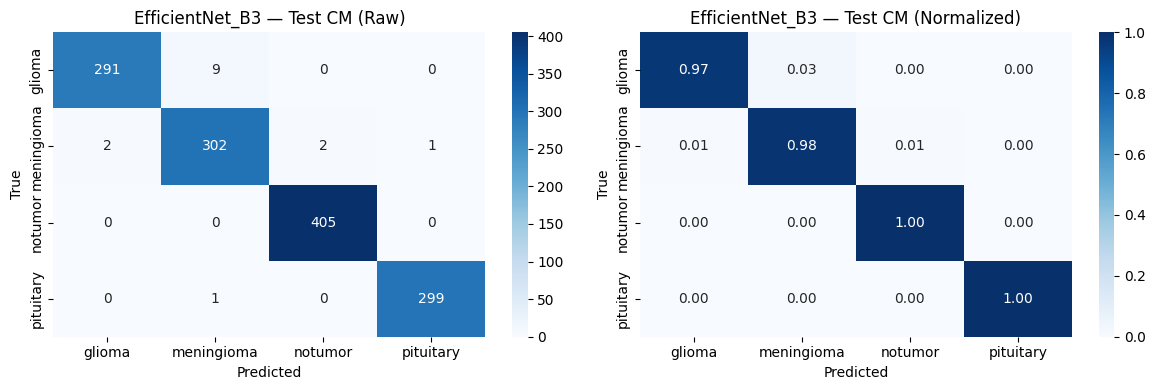

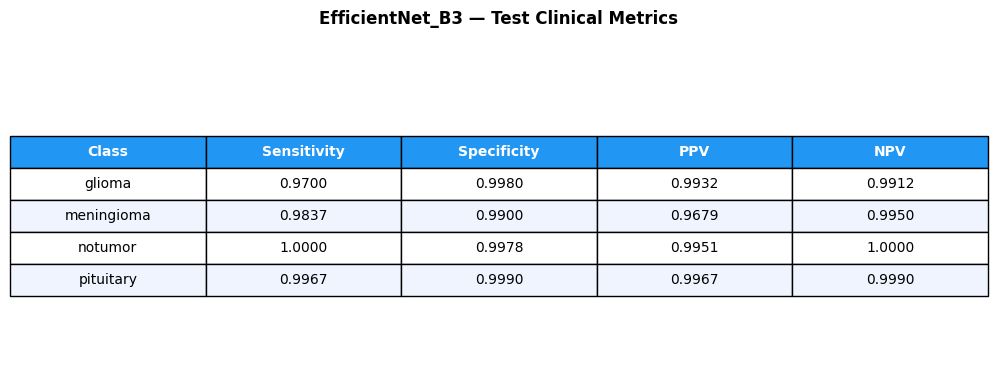

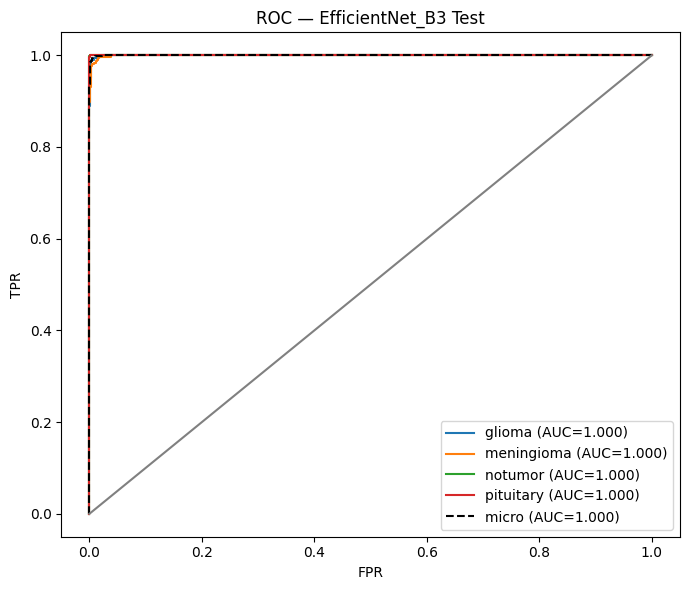

  ROC figure saved → results_EfficientNet_B3_Dataset1/roc_per_class_EfficientNet_B3_Test.png


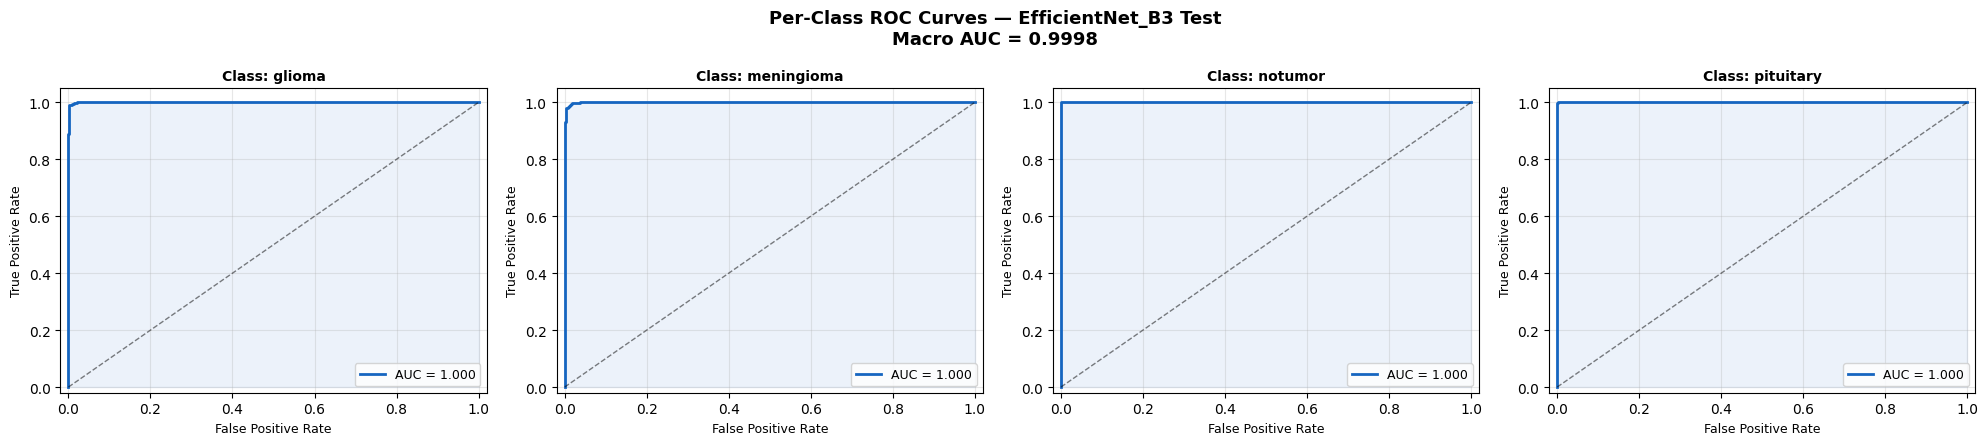


Bootstrap 95% CI (1000 resamples)...

Metric     Estimate                   95% CI
----------------------------------------------
acc          0.9885         [0.9825, 0.9939]
prec         0.9882         [0.9816, 0.9936]
rec          0.9875         [0.9808, 0.9934]
f1           0.9878         [0.9811, 0.9935]
kappa        0.9846         [0.9764, 0.9918]
mcc          0.9846         [0.9765, 0.9918]
auc          0.9998         [0.9996, 0.9999]

✅ Test artifacts → artifacts_EfficientNet_B3_Dataset1/


In [18]:
# FIXED: weights_only=False added for PyTorch 2.6+ compatibility
test_result   = None
test_preds_np = None
test_true_np  = None
test_probs_np = None

if best_fold_path and test_paths is not None:
    print(f"\n{'='*60}")
    print(f"Test Evaluation — Best Fold {best_fold_no}")
    print(f"{'='*60}")
    print(f"Loading: {best_fold_path}")

    # FIX: weights_only=False
    ckpt  = torch.load(best_fold_path, map_location=DEVICE, weights_only=False)
    model = build_efficientnet_b3(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    test_loader = DataLoader(
        BrainTumorDataset(test_paths, test_labels, test_transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    all_preds, all_lbls, all_logits = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            out = model(imgs.to(DEVICE))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_lbls.extend(lbls.numpy())
            all_logits.append(out.cpu().numpy())

    test_probs_np = softmax_np(np.concatenate(all_logits))
    test_preds_np = np.array(all_preds)
    test_true_np  = np.array(all_lbls)

    test_result = get_metrics(test_true_np, test_preds_np, test_probs_np)
    test_result["clinical"] = get_clinical_metrics(test_true_np, test_preds_np)

    print(f"\n{EXPERIMENT} — Test Set Performance:")
    print(f"  Acc   = {test_result['acc']:.4f}")
    print(f"  F1    = {test_result['f1']:.4f}")
    print(f"  AUC   = {test_result['auc']:.4f}")
    print(f"  Kappa = {test_result['kappa']:.4f}")
    print(f"  MCC   = {test_result['mcc']:.4f}")
    print("\n" + classification_report(test_true_np, test_preds_np,
          target_names=class_names, digits=4, zero_division=0))

    plot_cm(test_true_np, test_preds_np, title=f"{EXPERIMENT} — Test CM")
    plot_clinical_table(test_result["clinical"], title=f"{EXPERIMENT} — Test Clinical Metrics")
    try:
        plot_roc(test_true_np, test_probs_np, title_suffix=f"{EXPERIMENT} Test")
    except Exception as e:
        print(f"[WARN] ROC skipped: {e}")

    # Per-class ROC — publication figure
    try:
        plot_roc_per_class(
            test_true_np, test_probs_np,
            title_suffix=f"{EXPERIMENT} Test",
            save_dir=OUTPUT_DIR,
        )
    except Exception as e:
        print(f"[WARN] Per-class ROC skipped: {e}")

    print(f"\nBootstrap 95% CI ({BOOTSTRAP_N} resamples)...")
    test_ci = bootstrap_ci(test_true_np, test_preds_np, test_probs_np,
                            n=BOOTSTRAP_N, seed=SEED)
    print(f"\n{'Metric':<8} {'Estimate':>10} {'95% CI':>24}")
    print("-" * 46)
    for key, v in test_ci.items():
        if np.isnan(v["mean"]):
            print(f"{key:<8} {'N/A':>10} {'N/A':>24}")
        else:
            ci = f"[{v['lower']:.4f}, {v['upper']:.4f}]"
            print(f"{key:<8} {v['mean']:>10.4f} {ci:>24}")
    test_result["ci_95"] = test_ci

    np.save(os.path.join(ARTIFACTS_DIR, f"test_true_{EXPERIMENT}.npy"),  test_true_np)
    np.save(os.path.join(ARTIFACTS_DIR, f"test_pred_{EXPERIMENT}.npy"),  test_preds_np)
    np.save(os.path.join(ARTIFACTS_DIR, f"test_probs_{EXPERIMENT}.npy"), test_probs_np)
    print(f"\n✅ Test artifacts → {ARTIFACTS_DIR}/")

## 19. Misclassification analysis

In [ ]:
def plot_misclassified(paths, y_true, y_pred, class_names,
                        max_images=16, title="Misclassified Images"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    wrong_idx = np.where(y_true != y_pred)[0]
    total     = len(y_true)

    print("\n" + "="*65)
    print(f"Misclassification Report — {EXPERIMENT}")
    print("="*65)
    print(f"Total wrong: {len(wrong_idx)} / {total} ({100*len(wrong_idx)/total:.2f}%)")
    print(f"\n{'Class':15s} {'Wrong':>6} {'Total':>7} {'Error%':>8}  Confused with")
    print("-"*65)
    for i, cls in enumerate(class_names):
        cls_total = int(np.sum(y_true == i))
        cls_wrong = int(np.sum((y_true == i) & (y_pred != i)))
        err_pct   = 100 * cls_wrong / max(cls_total, 1)
        mask      = (y_true == i) & (y_pred != i)
        if mask.sum() > 0:
            mc = Counter(y_pred[mask].tolist()).most_common(1)[0]
            confused = f"{class_names[mc[0]]} ({mc[1]}x)"
        else:
            confused = "—"
        print(f"{cls:15s} {cls_wrong:>6d} {cls_total:>7d} {err_pct:>7.1f}%  {confused}")

    if len(wrong_idx) == 0:
        print("\n🎉 No misclassifications!")
        return

    sample_idx = wrong_idx[:max_images]
    cols = 4
    rows = (len(sample_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes_flat = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for ax, idx in zip(axes_flat, sample_idx):
        try:
            img = Image.open(paths[idx]).convert("RGB")
        except Exception:
            ax.axis("off"); continue
        ax.imshow(img)
        ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
                     color="#C62828", fontsize=9, fontweight="bold")
        ax.axis("off")
    for ax in axes_flat[len(sample_idx):]:
        ax.axis("off")

    plt.suptitle(f"{title} ({len(wrong_idx)} wrong / {total} total)",
                 fontsize=12, fontweight="bold", color="#B71C1C")
    plt.tight_layout(); plt.show()

if test_paths is not None and test_preds_np is not None:
    plot_misclassified(test_paths, test_true_np, test_preds_np, class_names,
                        max_images=16, title=f"{EXPERIMENT} — Misclassified")

## 20. Grad-CAM & Grad-CAM++ classes

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        hook = (target_layer.register_full_backward_hook
                if hasattr(target_layer, "register_full_backward_hook")
                else target_layer.register_backward_hook)
        hook(lambda m, gi, go: setattr(self, "gradients", go[0].detach()))

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        out[:, class_idx].backward()
        w   = self.gradients[0].mean(dim=(1, 2))
        cam = torch.relu((w[:, None, None] * self.activations[0]).sum(0))
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx

class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        hook = (target_layer.register_full_backward_hook
                if hasattr(target_layer, "register_full_backward_hook")
                else target_layer.register_backward_hook)
        hook(lambda m, gi, go: setattr(self, "gradients", go[0].detach()))

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        out[:, class_idx].backward()
        grads     = self.gradients[0]
        acts      = self.activations[0]
        grads_sq  = grads ** 2
        grads_cub = grads ** 3
        denom     = 2 * grads_sq + (acts * grads_cub).sum(dim=(1,2), keepdim=True) + 1e-8
        alpha     = grads_sq / denom
        weights   = (alpha * torch.relu(grads)).sum(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * acts).sum(0))
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx

print("✅ Grad-CAM & Grad-CAM++ ready")

## 21. LIME explainer

In [ ]:
def explain_with_lime(img_path, model, explainer, num_samples=500):
    model.eval()
    img_np = np.array(Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))

    def batch_predict(images):
        batch = [test_transform(image=im)["image"] for im in images]
        with torch.no_grad():
            out = model(torch.stack(batch).to(DEVICE))
        return softmax_np(out.cpu().numpy())

    explanation = explainer.explain_instance(
        img_np, batch_predict,
        top_labels=1, hide_color=0,
        num_samples=num_samples, random_seed=SEED)
    pred_class = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        pred_class, positive_only=True, num_features=10, hide_rest=False)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img_np); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title(f"LIME — {class_names[pred_class]}"); axes[1].axis("off")
    dict_heatmap = dict(explanation.local_exp[explanation.top_labels[0]])
    heatmap = np.vectorize(dict_heatmap.get)(explanation.segments)
    im = axes[2].imshow(heatmap, cmap="RdBu_r",
                         vmin=-abs(heatmap).max(), vmax=abs(heatmap).max())
    plt.colorbar(im, ax=axes[2]); axes[2].set_title("LIME Heatmap"); axes[2].axis("off")
    plt.suptitle(f"LIME — Predicted: {class_names[pred_class]}", fontweight="bold")
    plt.tight_layout(); plt.show()
    return explanation

print("✅ LIME ready")

## 22. XAI comparison (Grad-CAM vs Grad-CAM++ vs LIME)

✅ **FIXED** — `weights_only=False`


XAI Sample: /content/drive/MyDrive/Brain_MRI_Images/Testing/pituitary/Te-pi_0294.jpg

--- Grad-CAM vs Grad-CAM++ ---


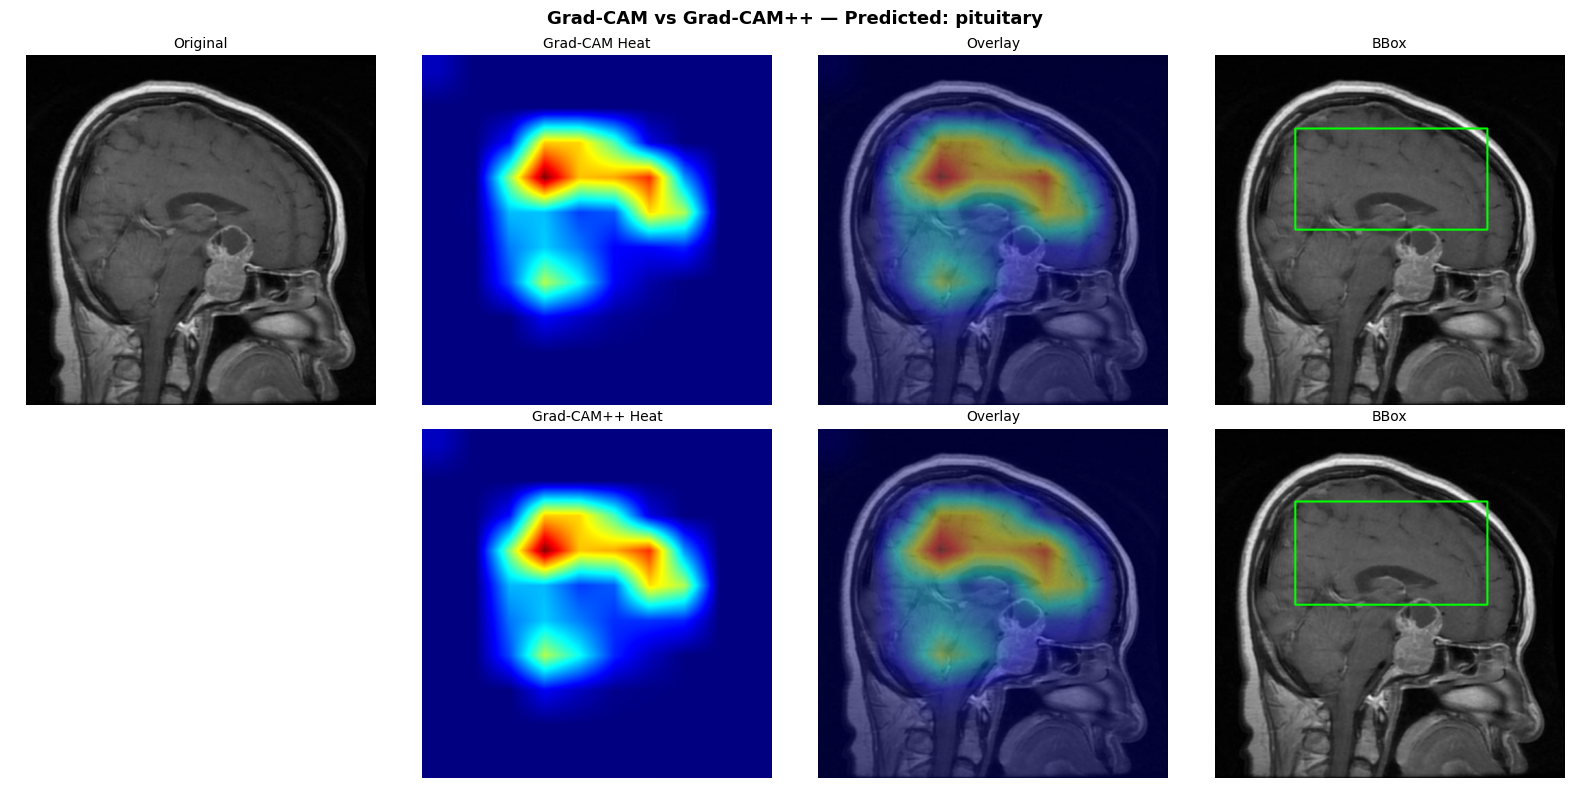


--- LIME Explanation ---


  0%|          | 0/500 [00:00<?, ?it/s]

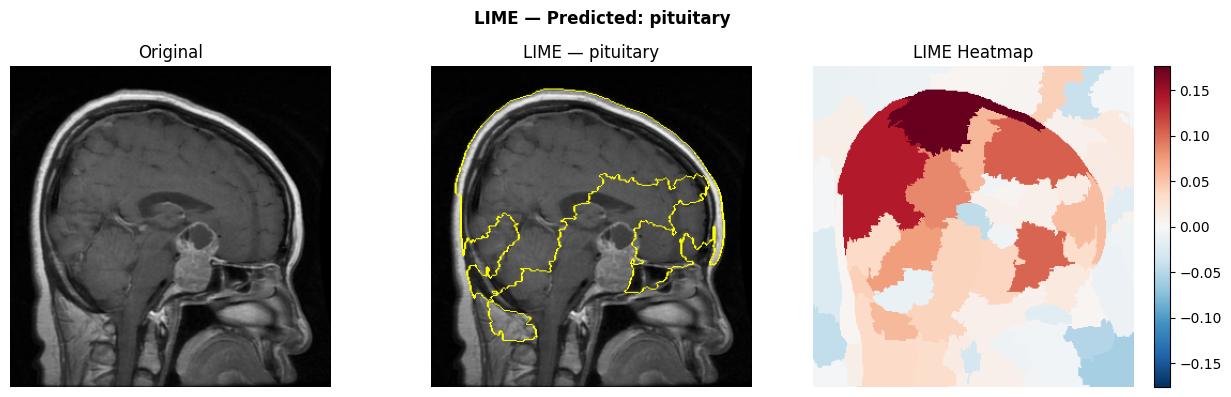

In [22]:
# FIXED: weights_only=False added for PyTorch 2.6+ compatibility
def show_xai_comparison(img_path, model, gradcam, gradcam_pp, thresh=0.4):
    img_np = np.array(Image.open(img_path).convert("RGB"))
    tensor = test_transform(image=img_np)["image"].unsqueeze(0).to(DEVICE)

    cam1, cidx = gradcam(tensor)
    cam2, _    = gradcam_pp(tensor)
    h, w, _    = img_np.shape

    def cam_to_vis(cam, img):
        cam_r   = cv2.resize(cam, (w, h))
        heatmap = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255*cam_r), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB)
        overlay = np.uint8(0.4*heatmap + 0.6*img)
        mask    = (cam_r >= cam_r.max()*thresh).astype(np.uint8) * 255
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        bbox    = img.copy()
        if cnts:
            x, y, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
            cv2.rectangle(bbox, (x,y), (x+bw, y+bh), (0,255,0), 2)
        return heatmap, overlay, bbox

    h1, o1, b1 = cam_to_vis(cam1, img_np)
    h2, o2, b2 = cam_to_vis(cam2, img_np)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    titles = ["Original", "Grad-CAM Heat", "Overlay", "BBox",
              "", "Grad-CAM++ Heat", "Overlay", "BBox"]
    images = [img_np, h1, o1, b1, None, h2, o2, b2]
    for ax, im, t in zip(axes.ravel(), images, titles):
        if im is None: ax.axis("off"); continue
        ax.imshow(im); ax.set_title(t, fontsize=10); ax.axis("off")
    plt.suptitle(f"Grad-CAM vs Grad-CAM++ — Predicted: {class_names[cidx]}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

if best_fold_path:
    # FIX: weights_only=False
    ckpt  = torch.load(best_fold_path, map_location=DEVICE, weights_only=False)
    model = build_efficientnet_b3(num_classes, FINE_TUNE_AT, tuple(DROPOUT_RATES))
    model.load_state_dict(ckpt["state_dict"]); model.eval()

    # EfficientNet-B3 Grad-CAM target layer:
    # model.features[-1] = features[8] = head Conv2dNormActivation (1536 output channels)
    # This is the last spatial feature map before global average pooling — ideal for CAM.
    gradcam    = GradCAM(model, model.features[-1])
    gradcam_pp = GradCAMPlusPlus(model, model.features[-1])
    lime_exp   = lime_image.LimeImageExplainer()

    sample = (random.choice(list(test_paths)) if test_paths is not None
              else random.choice(list(train_paths)))
    print(f"\nXAI Sample: {sample}")
    print("\n--- Grad-CAM vs Grad-CAM++ ---")
    show_xai_comparison(sample, model, gradcam, gradcam_pp)
    print("\n--- LIME Explanation ---")
    explain_with_lime(sample, model, lime_exp, num_samples=LIME_NUM_SAMPLES)

## 23. Per-class XAI grid (thesis figure)

In [ ]:
if best_fold_path:
    src_p = test_paths if test_paths is not None else train_paths
    src_l = test_labels if test_paths is not None else train_labels
    chosen = {}
    for p, l in zip(src_p, src_l):
        if class_names[l] not in chosen:
            chosen[class_names[l]] = p
        if len(chosen) == num_classes:
            break

    n = num_classes
    fig = plt.figure(figsize=(16, 4*n))
    gs  = gridspec.GridSpec(n, 4, figure=fig, hspace=0.35, wspace=0.15)

    for row, cls in enumerate(class_names):
        img_np = np.array(Image.open(chosen[cls]).convert("RGB"))
        h, w, _ = img_np.shape
        tensor  = test_transform(image=img_np)["image"].unsqueeze(0).to(DEVICE)

        cam1, _ = gradcam(tensor)
        cam2, _ = gradcam_pp(tensor)
        cam_r1  = cv2.resize(cam1, (w, h))
        cam_r2  = cv2.resize(cam2, (w, h))

        heat1 = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255*cam_r1), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB)
        heat2 = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255*cam_r2), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB)
        ov1 = np.uint8(0.4*heat1 + 0.6*img_np)
        ov2 = np.uint8(0.4*heat2 + 0.6*img_np)

        mask = (cam_r2 >= cam_r2.max()*0.4).astype(np.uint8) * 255
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        bbox_img = img_np.copy()
        if cnts:
            x, y, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
            cv2.rectangle(bbox_img, (x,y), (x+bw, y+bh), (0,255,0), 2)

        for col, (im, t) in enumerate(zip(
            [img_np, ov1, ov2, bbox_img],
            [f"{cls}\nOriginal", "Grad-CAM", "Grad-CAM++", "BBox (CAM++)"])):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(im); ax.set_title(t, fontsize=10); ax.axis("off")

    plt.suptitle(f"{EXPERIMENT} — Per-Class XAI Visualization",
                 fontsize=14, fontweight="bold")
    xai_path = os.path.join(OUTPUT_DIR, f"{EXPERIMENT}_XAI_grid.png")
    plt.savefig(xai_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ XAI grid saved → {xai_path}")

## 24. McNemar test helper (for cross-model comparison)

In [24]:
def mcnemar_compare_from_files(model_a, model_b, artifacts_dir=None):
    """Compare predictions from two saved models via McNemar test."""
    if artifacts_dir is None:
        artifacts_dir = ARTIFACTS_DIR
    y_true = np.load(os.path.join(artifacts_dir, f"test_true_{model_a}.npy"))
    pa     = np.load(os.path.join(artifacts_dir, f"test_pred_{model_a}.npy"))
    pb     = np.load(os.path.join(artifacts_dir, f"test_pred_{model_b}.npy"))
    ca, cb = (pa == y_true), (pb == y_true)
    n11 = int(np.sum( ca &  cb))
    n10 = int(np.sum( ca & ~cb))
    n01 = int(np.sum(~ca &  cb))
    n00 = int(np.sum(~ca & ~cb))
    result = mcnemar_test([[n11, n10], [n01, n00]], exact=True)
    print(f"\nMcNemar: {model_a} vs {model_b}")
    print(f"  Both correct: {n11} | {model_a} only: {n10} | "
          f"{model_b} only: {n01} | Both wrong: {n00}")
    print(f"  p-value: {result.pvalue:.4f} "
          f"({'SIGNIFICANT' if result.pvalue < 0.05 else 'not significant'})")
    return {
        "model_a": model_a, "model_b": model_b,
        "n11": n11, "n10": n10, "n01": n01, "n00": n00,
        "p_value": float(result.pvalue),
        "significant": bool(result.pvalue < 0.05),
    }

print(f"✅ McNemar ready. After running VGG16, run:")
print(f"   mcnemar_compare_from_files('{EXPERIMENT}', 'VGG16')")

✅ McNemar ready. After running VGG16, run:
   mcnemar_compare_from_files('EfficientNet_B3', 'VGG16')


## 25. Save results JSON

In [ ]:
def to_serial(obj):
    if isinstance(obj, np.generic):      return obj.item()
    if isinstance(obj, np.ndarray):      return obj.tolist()
    if isinstance(obj, dict):            return {k: to_serial(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):   return [to_serial(x) for x in obj]
    return obj

cv_summary = {}
for key in ["acc", "prec", "rec", "f1", "auc", "kappa", "mcc"]:
    vals = np.array([m[key] for m in all_fold_metrics], dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) > 0:
        boot = [np.mean(np.random.RandomState(i).choice(vals, size=len(vals), replace=True))
                for i in range(BOOTSTRAP_N)]
        cv_summary[key] = {
            "mean":  float(np.mean(vals)),
            "std":   float(np.std(vals)),
            "lower": float(np.percentile(boot, 2.5)),
            "upper": float(np.percentile(boot, 97.5)),
        }

results = {
    "experiment":    EXPERIMENT,
    "dataset":       DATASET_NAME,
    "run_id":        RUN_ID,
    "timestamp":     datetime.now().isoformat(),
    "model_info":    MODEL_INFO,
    "class_names":   class_names,
    "num_classes":   num_classes,
    "train_size":    int(len(train_paths)),
    "test_size":     int(len(test_paths)) if test_paths is not None else 0,
    "fold_metrics":  all_fold_metrics,
    "cv_summary":    cv_summary,
    "best_fold":     best_fold_no,
    "best_fold_path": best_fold_path,
    "training_time": {
        "per_fold_sec": [m["train_time_sec"] for m in all_fold_metrics],
        "avg_fold_min": float(np.mean([m["train_time_sec"] for m in all_fold_metrics]) / 60),
        "total_min":    float(sum(m["train_time_sec"] for m in all_fold_metrics) / 60),
    },
    "test_metrics":  test_result,
    "artifacts_dir": ARTIFACTS_DIR,
    "ckpt_dir":      CKPT_DIR,
    "xai_methods":   ["Grad-CAM", "Grad-CAM++", "LIME"],
}

result_path = os.path.join(OUTPUT_DIR, f"results_{EXPERIMENT}_{DATASET_NAME}_{RUN_ID}.json")
with open(result_path, "w") as f:
    json.dump(to_serial(results), f, indent=2)
print(f"\n✅ Results saved → {result_path}")

## 26. Publication-ready summary table

In [26]:
print(f"\n{'='*85}")
print(f"{EXPERIMENT} on {DATASET_NAME} — PUBLICATION SUMMARY")
print(f"{'='*85}")
print(f"{'Metric':<10} {'CV Mean':>10} {'CV 95% CI':>24} {'Test':>10} {'Test 95% CI':>24}")
print("-" * 85)
for key in ["acc", "prec", "rec", "f1", "auc", "kappa", "mcc"]:
    cv_v  = cv_summary.get(key, {})
    cv_m  = cv_v.get("mean",  float("nan"))
    cv_l  = cv_v.get("lower", float("nan"))
    cv_u  = cv_v.get("upper", float("nan"))
    tst_v = test_result["ci_95"].get(key, {}) if test_result else {}
    tst_m = test_result.get(key, float("nan")) if test_result else float("nan")
    tst_l = tst_v.get("lower", float("nan"))
    tst_u = tst_v.get("upper", float("nan"))

    cv_ci_str  = f"[{cv_l:.4f}, {cv_u:.4f}]" if not np.isnan(cv_l) else "N/A"
    tst_ci_str = f"[{tst_l:.4f}, {tst_u:.4f}]" if not np.isnan(tst_l) else "N/A"
    marker     = "  <-" if key == BEST_METRIC else ""
    print(f"{key:<10} {cv_m:>10.4f} {cv_ci_str:>24} {tst_m:>10.4f} {tst_ci_str:>24}{marker}")

print("=" * 85)
if test_result is not None:
    print("\nLaTeX table row (copy-paste ready):")
    print(f"EfficientNet-B3 & {test_result['acc']*100:.2f} & {test_result['prec']*100:.2f} & "
          f"{test_result['rec']*100:.2f} & {test_result['f1']*100:.2f} & "
          f"{test_result['auc']*100:.2f} & {test_result['kappa']:.3f} & "
          f"{test_result['mcc']:.3f} \\\\")

print(f"\n✅ DONE! All outputs in:")
print(f"   Results    : {OUTPUT_DIR}/")
print(f"   Checkpoints: {CKPT_DIR}/")
print(f"   Artifacts  : {ARTIFACTS_DIR}/")


EfficientNet_B3 on Dataset1 — PUBLICATION SUMMARY
Metric        CV Mean                CV 95% CI       Test              Test 95% CI
-------------------------------------------------------------------------------------
acc            0.9828         [0.9804, 0.9849]     0.9886         [0.9825, 0.9939]
prec           0.9823         [0.9798, 0.9844]     0.9882         [0.9816, 0.9936]
rec            0.9830         [0.9803, 0.9852]     0.9876         [0.9808, 0.9934]
f1             0.9826         [0.9799, 0.9847]     0.9879         [0.9811, 0.9935]  <-
auc            0.9928         [0.9915, 0.9940]     0.9998         [0.9996, 0.9999]
kappa          0.9771         [0.9738, 0.9799]     0.9847         [0.9764, 0.9918]
mcc            0.9771         [0.9739, 0.9799]     0.9847         [0.9765, 0.9918]

LaTeX table row (copy-paste ready):
EfficientNet-B3 & 98.86 & 98.82 & 98.76 & 98.79 & 99.98 & 0.985 & 0.985 \\

✅ DONE! All outputs in:
   Results    : results_EfficientNet_B3_Dataset1/
   Check